# 实验1： 绘制不同耦合强度下的组图

## 改变耦合强度

In [12]:
from giant_atom_generate_correlation_function import *
import time 
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
from functools import lru_cache
import json
# Physical / spectral parameters (edit as needed)
# mu        = 3.0     # \bar{ω}
# tau       = 0.229   # 寿命为0.229ns
# delta_t   = 3 * tau     #
# sigma     = 1/delta_t     # spectral width,即波的长度，delta_t
beta      = 1.0 #理想情况下取beta=1，Gamma0=0
# gamma_tot = 1/tau 
Gamma0    = 0.0
omega0    = 5.8
mu        = omega0    # \bar{ω}
Np1       = 1
Np2       = 1
T1        = 0
T2        = 0
# wmax      = 40 * sigma #积分区域的偏置

# g1 = 1.0/mp.sqrt(mp.pi * tau) /4    # 也可以是复数，如 0.1 + 0.02j
# g2 = 1.0/mp.sqrt(mp.pi * tau) /4     # 1/mp.sqrt(mp.pi * tau) /4这个值对应于小原子的情况
# phi0 = 2/mp.pi #相位
test_direction1 = 't'#r反射，t透射;即r对应左侧输出， t对应右侧输出
test_direction2 = 't'
name = 'R1_giant_atom_g1g2_tt_resonance_coupling_test1_v2.npz'

# g1    = mp.mpc(g1)
# g2    = mp.mpc(g2)
# Delta = mp.mpf(Delta)
# phi0  = mp.mpf(phi0)
# Build ψ^(2) with the above parameters
# psi2 = make_psi2(mu, sigma, beta, gamma_tot, Gamma0,omega0,
#                     use_infinite_limits=False, L=wmax)
use_infinite_limits=True

# ========== t1,t2 网格 ==========
t1_min, t1_max, n_t1 = -3,6, 271
t2_min, t2_max, n_t2 = -3,6, 271
t1_vals = np.linspace(t1_min, t1_max, n_t1)
t2_vals = np.linspace(t2_min, t2_max, n_t2)

# ========== 计算 |N| (也可改为实部或模方，见下方注释) ==========
Z_Nval = np.empty((n_t2, n_t1), dtype=float)  # 行对应 t2，列对应 t1
Z_Nval1 = np.empty((n_t2, n_t1), dtype=complex)  # 行对应 t2，列对应 t1
Z_Nval2 = np.empty((n_t2, n_t1), dtype=complex)  # 行对应 t2，列对应 t1

# ====== 先计算并存储 12 组结果 ======
Z_Nval_allrr  = []
Z_Nval1_allrr = []
Z_Nval2_allrr = []
phi_list = []
ratio = [0.1,0.5,0.8,1,1.2,1.5,2.0,3.0,5.0] # delta_t/tau，即比例
# ratio = [0.05,0.25,0.4,0.5,0.6,0.75,1.0,1.5,2.5] # delta_t/tau，即比例
# matrix = [0.025,0.05,0.1,0.5] 

# 数据存储初始化
K = len(ratio)
global_params = dict(
    beta=float(beta),
    Gamma0=float(Gamma0),
    omega0=float(omega0),
    mu=float(mu),
    # Delta=float(Delta),
    test_direction1=test_direction1,
    test_direction2=test_direction2,
    use_infinite_limits=bool(use_infinite_limits),
    t1_min=float(t1_min), t1_max=float(t1_max), n_t1=int(n_t1),
    t2_min=float(t2_min), t2_max=float(t2_max), n_t2=int(n_t2),
)

per_k_params = []                 # 每个k的参数字典
magnification = np.empty(K)       # delta_t/tau



magnification = ratio 
for k in range(9):
    # phi0 = (k+1) * mp.pi/6
    # delta_t =matrix[k] * tau
    phi0 =  mp.pi/2
    delta_t = 1e2 # 时域展宽
    tau       = delta_t/(ratio[k])  
    # delta_t   = 1 * tau     #
    sigma     = 1/delta_t     # spectral width,即波的长度，delta_t
    wmax = 40 * sigma
    g1 = 1.0/(mp.sqrt(2 * mp.pi * tau * 4 * (1+mp.cos(phi0))))    # 也可以是复数，如 0.1 + 0.02j
    g2 = 1.0/(mp.sqrt(2 * mp.pi * tau * 4 * (1+mp.cos(phi0))))     # 1/mp.sqrt(mp.pi * tau) /4这个值对应于小原子的情况
    Delta = - 4 * mp.pi * mp.re(g1 * mp.conj(g2)) * mp.sin(phi0)

    # g1     = matrix[k] /2 
    # g2     = matrix[k] /2 
    phi_list.append(float(phi0))

    psi2 = make_psi2(mu, sigma,
                     Delta, g1, g2, phi0, omega0,
                     use_infinite_limits=use_infinite_limits, L=wmax)

    Z_Nval  = np.empty((n_t2, n_t1), dtype=float)
    Z_Nval1 = np.empty((n_t2, n_t1), dtype=complex)
    Z_Nval2 = np.empty((n_t2, n_t1), dtype=complex)

    # 存储每一个循环的数据
    per_k_params.append(dict(
        k=int(k),
        ratio=float(ratio[k]),
        T1=float(T1), T2=float(T2),
        Np1=int(Np1), Np2=int(Np2),
        phi0=float(phi0),
        tau=float(tau),
        delta_t=float(delta_t),
        sigma=float(sigma),
        wmax=float(wmax),
        g1=complex(g1),
        g2=complex(g2),
        Delta = complex(Delta),
    ))

    magnification[k] = float(delta_t / tau)

    for j, t2 in enumerate(t2_vals):
        for i, t1 in enumerate(t1_vals):
            start_time = time.time()

            Nval1 = psi2(t1 * delta_t, t2 * delta_t, T1, Np1, T2, Np2,
                         test_direction1, test_direction2)

            Nval2 = N_of_t(t1 * delta_t, t2 * delta_t, mu, sigma,
                           Delta, g1, g2, phi0, omega0, T1, Np1, T2, Np2,
                           test_direction1, test_direction2,
                           use_infinite_limits=use_infinite_limits, wmax=wmax)

            # 你的调试输出保留（不需要可删）
            # print(time.time() - start_time)
            # print(Nval1, Nval2)

            Z_Nval1[j, i] = complex(Nval1)
            Z_Nval2[j, i] = complex(Nval2)

            Nc = complex(Nval1) + complex(Nval2)
            Z_Nval[j, i] = abs(Nc) ** 2

    Z_Nval_allrr.append(Z_Nval)
    Z_Nval1_allrr.append(Z_Nval1)
    Z_Nval2_allrr.append(Z_Nval2)
    magnification[k] = delta_t/tau

# 数据存储
# 3D: (K, n_t2, n_t1)
Nval1_all = np.stack(Z_Nval1_allrr, axis=0).astype(np.complex128)
Nval2_all = np.stack(Z_Nval2_allrr, axis=0).astype(np.complex128)
Nc_abs2_all = np.stack(Z_Nval_allrr, axis=0).astype(np.float64)

np.savez_compressed(
    name,
    global_params=np.array([global_params], dtype=object),
    per_k_params=np.array(per_k_params, dtype=object),
    t1_vals=t1_vals,
    t2_vals=t2_vals,
    ratio=np.array(ratio, dtype=float),
    magnification=magnification,
    Nval1=Nval1_all,
    Nval2=Nval2_all,
    Nc_abs2=Nc_abs2_all,
)

# # 可选：单独存一个纯文本参数文件（更好读）
# with open("giant_atom_corr_params.json", "w", encoding="utf-8") as f:
#     json.dump(
#         {"global_params": global_params, "per_k_params": per_k_params},
#         f, ensure_ascii=False, indent=2,
#         default=lambda o: str(o)  # 避免 mp 类型报错
#     )

print("Saved: {name}")





Saved: {name}


In [13]:
from giant_atom_generate_correlation_function import *
import time 
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
from functools import lru_cache
import json
# Physical / spectral parameters (edit as needed)
# mu        = 3.0     # \bar{ω}
# tau       = 0.229   # 寿命为0.229ns
# delta_t   = 3 * tau     #
# sigma     = 1/delta_t     # spectral width,即波的长度，delta_t
beta      = 1.0 #理想情况下取beta=1，Gamma0=0
# gamma_tot = 1/tau 
Gamma0    = 0.0
omega0    = 5.8
mu        = omega0    # \bar{ω}
Np1       = 1
Np2       = 1
T1        = 0
T2        = 0
# wmax      = 40 * sigma #积分区域的偏置

# g1 = 1.0/mp.sqrt(mp.pi * tau) /4    # 也可以是复数，如 0.1 + 0.02j
# g2 = 1.0/mp.sqrt(mp.pi * tau) /4     # 1/mp.sqrt(mp.pi * tau) /4这个值对应于小原子的情况
# phi0 = 2/mp.pi #相位
test_direction1 = 'r'#r反射，t透射;即r对应左侧输出， t对应右侧输出
test_direction2 = 'r'
name = 'R1_giant_atom_g1g2_rr_resonance_coupling_test1_v2.npz'

# g1    = mp.mpc(g1)
# g2    = mp.mpc(g2)
# Delta = mp.mpf(Delta)
# phi0  = mp.mpf(phi0)
# Build ψ^(2) with the above parameters
# psi2 = make_psi2(mu, sigma, beta, gamma_tot, Gamma0,omega0,
#                     use_infinite_limits=False, L=wmax)
use_infinite_limits=True

# ========== t1,t2 网格 ==========
t1_min, t1_max, n_t1 = -3,6, 271
t2_min, t2_max, n_t2 = -3,6, 271
t1_vals = np.linspace(t1_min, t1_max, n_t1)
t2_vals = np.linspace(t2_min, t2_max, n_t2)

# ========== 计算 |N| (也可改为实部或模方，见下方注释) ==========
Z_Nval = np.empty((n_t2, n_t1), dtype=float)  # 行对应 t2，列对应 t1
Z_Nval1 = np.empty((n_t2, n_t1), dtype=complex)  # 行对应 t2，列对应 t1
Z_Nval2 = np.empty((n_t2, n_t1), dtype=complex)  # 行对应 t2，列对应 t1

# ====== 先计算并存储 12 组结果 ======
Z_Nval_allrr  = []
Z_Nval1_allrr = []
Z_Nval2_allrr = []
phi_list = []
# ratio = [0.05,0.25,0.4,0.5,0.6,0.75,1.0,1.5,2.5] # delta_t/tau，即比例
ratio = [0.1,0.5,0.8,1,1.2,1.5,2.0,3.0,5.0] # delta_t/tau，即比例
# matrix = [0.025,0.05,0.1,0.5] 

# 数据存储初始化
K = len(ratio)
global_params = dict(
    beta=float(beta),
    Gamma0=float(Gamma0),
    omega0=float(omega0),
    mu=float(mu),
    # Delta=float(Delta),
    test_direction1=test_direction1,
    test_direction2=test_direction2,
    use_infinite_limits=bool(use_infinite_limits),
    t1_min=float(t1_min), t1_max=float(t1_max), n_t1=int(n_t1),
    t2_min=float(t2_min), t2_max=float(t2_max), n_t2=int(n_t2),
)

per_k_params = []                 # 每个k的参数字典
magnification = np.empty(K)       # delta_t/tau



magnification = ratio 
for k in range(9):
    # phi0 = (k+1) * mp.pi/6
    # delta_t =matrix[k] * tau
    phi0 =  mp.pi/2
    delta_t = 1e2 # 时域展宽
    tau       = delta_t/(ratio[k])  
    # delta_t   = 1 * tau     #
    sigma     = 1/delta_t     # spectral width,即波的长度，delta_t
    wmax = 40 * sigma
    g1 = 1.0/(mp.sqrt(2 * mp.pi * tau * 4 * (1+mp.cos(phi0))))    # 也可以是复数，如 0.1 + 0.02j
    g2 = 1.0/(mp.sqrt(2 * mp.pi * tau * 4 * (1+mp.cos(phi0))))    # 1/mp.sqrt(mp.pi * tau) /4这个值对应于小原子的情况
    Delta = - 4 * mp.pi * mp.re(g1 * mp.conj(g2)) * mp.sin(phi0)

    # g1     = matrix[k] /2 
    # g2     = matrix[k] /2 
    phi_list.append(float(phi0))

    psi2 = make_psi2(mu, sigma,
                     Delta, g1, g2, phi0, omega0,
                     use_infinite_limits=use_infinite_limits, L=wmax)

    Z_Nval  = np.empty((n_t2, n_t1), dtype=float)
    Z_Nval1 = np.empty((n_t2, n_t1), dtype=complex)
    Z_Nval2 = np.empty((n_t2, n_t1), dtype=complex)

    # 存储每一个循环的数据
    per_k_params.append(dict(
        k=int(k),
        ratio=float(ratio[k]),
        T1=float(T1), T2=float(T2),
        Np1=int(Np1), Np2=int(Np2),
        phi0=float(phi0),
        tau=float(tau),
        delta_t=float(delta_t),
        sigma=float(sigma),
        wmax=float(wmax),
        g1=complex(g1),
        g2=complex(g2),
        Delta = complex(Delta),
    ))

    magnification[k] = float(delta_t / tau)

    for j, t2 in enumerate(t2_vals):
        for i, t1 in enumerate(t1_vals):
            start_time = time.time()

            Nval1 = psi2(t1 * delta_t, t2 * delta_t, T1, Np1, T2, Np2,
                         test_direction1, test_direction2)

            Nval2 = N_of_t(t1 * delta_t, t2 * delta_t, mu, sigma,
                           Delta, g1, g2, phi0, omega0, T1, Np1, T2, Np2,
                           test_direction1, test_direction2,
                           use_infinite_limits=use_infinite_limits, wmax=wmax)

            # 你的调试输出保留（不需要可删）
            # print(time.time() - start_time)
            # print(Nval1, Nval2)

            Z_Nval1[j, i] = complex(Nval1)
            Z_Nval2[j, i] = complex(Nval2)

            Nc = complex(Nval1) + complex(Nval2)
            Z_Nval[j, i] = abs(Nc) ** 2

    Z_Nval_allrr.append(Z_Nval)
    Z_Nval1_allrr.append(Z_Nval1)
    Z_Nval2_allrr.append(Z_Nval2)
    magnification[k] = delta_t/tau

# 数据存储
# 3D: (K, n_t2, n_t1)
Nval1_all = np.stack(Z_Nval1_allrr, axis=0).astype(np.complex128)
Nval2_all = np.stack(Z_Nval2_allrr, axis=0).astype(np.complex128)
Nc_abs2_all = np.stack(Z_Nval_allrr, axis=0).astype(np.float64)

np.savez_compressed(
    name,
    global_params=np.array([global_params], dtype=object),
    per_k_params=np.array(per_k_params, dtype=object),
    t1_vals=t1_vals,
    t2_vals=t2_vals,
    ratio=np.array(ratio, dtype=float),
    magnification=magnification,
    Nval1=Nval1_all,
    Nval2=Nval2_all,
    Nc_abs2=Nc_abs2_all,
)

# # 可选：单独存一个纯文本参数文件（更好读）
# with open("giant_atom_corr_params.json", "w", encoding="utf-8") as f:
#     json.dump(
#         {"global_params": global_params, "per_k_params": per_k_params},
#         f, ensure_ascii=False, indent=2,
#         default=lambda o: str(o)  # 避免 mp 类型报错
#     )

print("Saved: {name}")





Saved: {name}


In [14]:
from giant_atom_generate_correlation_function import *
import time 
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
from functools import lru_cache
import json
# Physical / spectral parameters (edit as needed)
# mu        = 3.0     # \bar{ω}
# tau       = 0.229   # 寿命为0.229ns
# delta_t   = 3 * tau     #
# sigma     = 1/delta_t     # spectral width,即波的长度，delta_t
beta      = 1.0 #理想情况下取beta=1，Gamma0=0
# gamma_tot = 1/tau 
Gamma0    = 0.0
omega0    = 5.8
mu        = omega0    # \bar{ω}
Np1       = 1
Np2       = 1
T1        = 0
T2        = 0
# wmax      = 40 * sigma #积分区域的偏置

# g1 = 1.0/mp.sqrt(mp.pi * tau) /4    # 也可以是复数，如 0.1 + 0.02j
# g2 = 1.0/mp.sqrt(mp.pi * tau) /4     # 1/mp.sqrt(mp.pi * tau) /4这个值对应于小原子的情况
# phi0 = 2/mp.pi #相位
test_direction1 = 't'#r反射，t透射;即r对应左侧输出， t对应右侧输出
test_direction2 = 'r'
name = 'R1_giant_atom_g1g2_tr_resonance_coupling_test1_v2.npz'

# g1    = mp.mpc(g1)
# g2    = mp.mpc(g2)
# Delta = mp.mpf(Delta)
# phi0  = mp.mpf(phi0)
# Build ψ^(2) with the above parameters
# psi2 = make_psi2(mu, sigma, beta, gamma_tot, Gamma0,omega0,
#                     use_infinite_limits=False, L=wmax)
use_infinite_limits=True

# ========== t1,t2 网格 ==========
t1_min, t1_max, n_t1 = -3,6, 271
t2_min, t2_max, n_t2 = -3,6, 271
t1_vals = np.linspace(t1_min, t1_max, n_t1)
t2_vals = np.linspace(t2_min, t2_max, n_t2)

# ========== 计算 |N| (也可改为实部或模方，见下方注释) ==========
Z_Nval = np.empty((n_t2, n_t1), dtype=float)  # 行对应 t2，列对应 t1
Z_Nval1 = np.empty((n_t2, n_t1), dtype=complex)  # 行对应 t2，列对应 t1
Z_Nval2 = np.empty((n_t2, n_t1), dtype=complex)  # 行对应 t2，列对应 t1

# ====== 先计算并存储 12 组结果 ======
Z_Nval_allrr  = []
Z_Nval1_allrr = []
Z_Nval2_allrr = []
phi_list = []
# ratio = [0.05,0.25,0.4,0.5,0.6,0.75,1.0,1.5,2.5] # delta_t/tau，即比例
ratio = [0.1,0.5,0.8,1,1.2,1.5,2.0,3.0,5.0] # delta_t/tau，即比例
# matrix = [0.025,0.05,0.1,0.5] 

# 数据存储初始化
K = len(ratio)
global_params = dict(
    beta=float(beta),
    Gamma0=float(Gamma0),
    omega0=float(omega0),
    mu=float(mu),
    # Delta=float(Delta),
    test_direction1=test_direction1,
    test_direction2=test_direction2,
    use_infinite_limits=bool(use_infinite_limits),
    t1_min=float(t1_min), t1_max=float(t1_max), n_t1=int(n_t1),
    t2_min=float(t2_min), t2_max=float(t2_max), n_t2=int(n_t2),
)

per_k_params = []                 # 每个k的参数字典
magnification = np.empty(K)       # delta_t/tau



magnification = ratio 
for k in range(9):
    # phi0 = (k+1) * mp.pi/6
    # delta_t =matrix[k] * tau
    phi0 =  mp.pi/2
    delta_t = 1e2 # 时域展宽
    tau       = delta_t/(ratio[k])  
    # delta_t   = 1 * tau     #
    sigma     = 1/delta_t     # spectral width,即波的长度，delta_t
    wmax = 40 * sigma
    g1 = 1.0/(mp.sqrt(2 * mp.pi * tau * 4 * (1+mp.cos(phi0))))    # 也可以是复数，如 0.1 + 0.02j
    g2 = 1.0/(mp.sqrt(2 * mp.pi * tau * 4 * (1+mp.cos(phi0))))     # 1/mp.sqrt(mp.pi * tau) /4这个值对应于小原子的情况
    Delta = - 4 * mp.pi * mp.re(g1 * mp.conj(g2)) * mp.sin(phi0)

    # g1     = matrix[k] /2 
    # g2     = matrix[k] /2 
    phi_list.append(float(phi0))

    psi2 = make_psi2(mu, sigma,
                     Delta, g1, g2, phi0, omega0,
                     use_infinite_limits=use_infinite_limits, L=wmax)

    Z_Nval  = np.empty((n_t2, n_t1), dtype=float)
    Z_Nval1 = np.empty((n_t2, n_t1), dtype=complex)
    Z_Nval2 = np.empty((n_t2, n_t1), dtype=complex)

    # 存储每一个循环的数据
    per_k_params.append(dict(
        k=int(k),
        ratio=float(ratio[k]),
        T1=float(T1), T2=float(T2),
        Np1=int(Np1), Np2=int(Np2),
        phi0=float(phi0),
        tau=float(tau),
        delta_t=float(delta_t),
        sigma=float(sigma),
        wmax=float(wmax),
        g1=complex(g1),
        g2=complex(g2),
        Delta = complex(Delta),
    ))

    magnification[k] = float(delta_t / tau)

    for j, t2 in enumerate(t2_vals):
        for i, t1 in enumerate(t1_vals):
            start_time = time.time()

            Nval1 = psi2(t1 * delta_t, t2 * delta_t, T1, Np1, T2, Np2,
                         test_direction1, test_direction2)

            Nval2 = N_of_t(t1 * delta_t, t2 * delta_t, mu, sigma,
                           Delta, g1, g2, phi0, omega0, T1, Np1, T2, Np2,
                           test_direction1, test_direction2,
                           use_infinite_limits=use_infinite_limits, wmax=wmax)

            # 你的调试输出保留（不需要可删）
            # print(time.time() - start_time)
            # print(Nval1, Nval2)

            Z_Nval1[j, i] = complex(Nval1)
            Z_Nval2[j, i] = complex(Nval2)

            Nc = complex(Nval1) + complex(Nval2)
            Z_Nval[j, i] = abs(Nc) ** 2

    Z_Nval_allrr.append(Z_Nval)
    Z_Nval1_allrr.append(Z_Nval1)
    Z_Nval2_allrr.append(Z_Nval2)
    magnification[k] = delta_t/tau

# 数据存储
# 3D: (K, n_t2, n_t1)
Nval1_all = np.stack(Z_Nval1_allrr, axis=0).astype(np.complex128)
Nval2_all = np.stack(Z_Nval2_allrr, axis=0).astype(np.complex128)
Nc_abs2_all = np.stack(Z_Nval_allrr, axis=0).astype(np.float64)

np.savez_compressed(
    name,
    global_params=np.array([global_params], dtype=object),
    per_k_params=np.array(per_k_params, dtype=object),
    t1_vals=t1_vals,
    t2_vals=t2_vals,
    ratio=np.array(ratio, dtype=float),
    magnification=magnification,
    Nval1=Nval1_all,
    Nval2=Nval2_all,
    Nc_abs2=Nc_abs2_all,
)

# # 可选：单独存一个纯文本参数文件（更好读）
# with open("giant_atom_corr_params.json", "w", encoding="utf-8") as f:
#     json.dump(
#         {"global_params": global_params, "per_k_params": per_k_params},
#         f, ensure_ascii=False, indent=2,
#         default=lambda o: str(o)  # 避免 mp 类型报错
#     )

print("Saved: {name}")





Saved: {name}


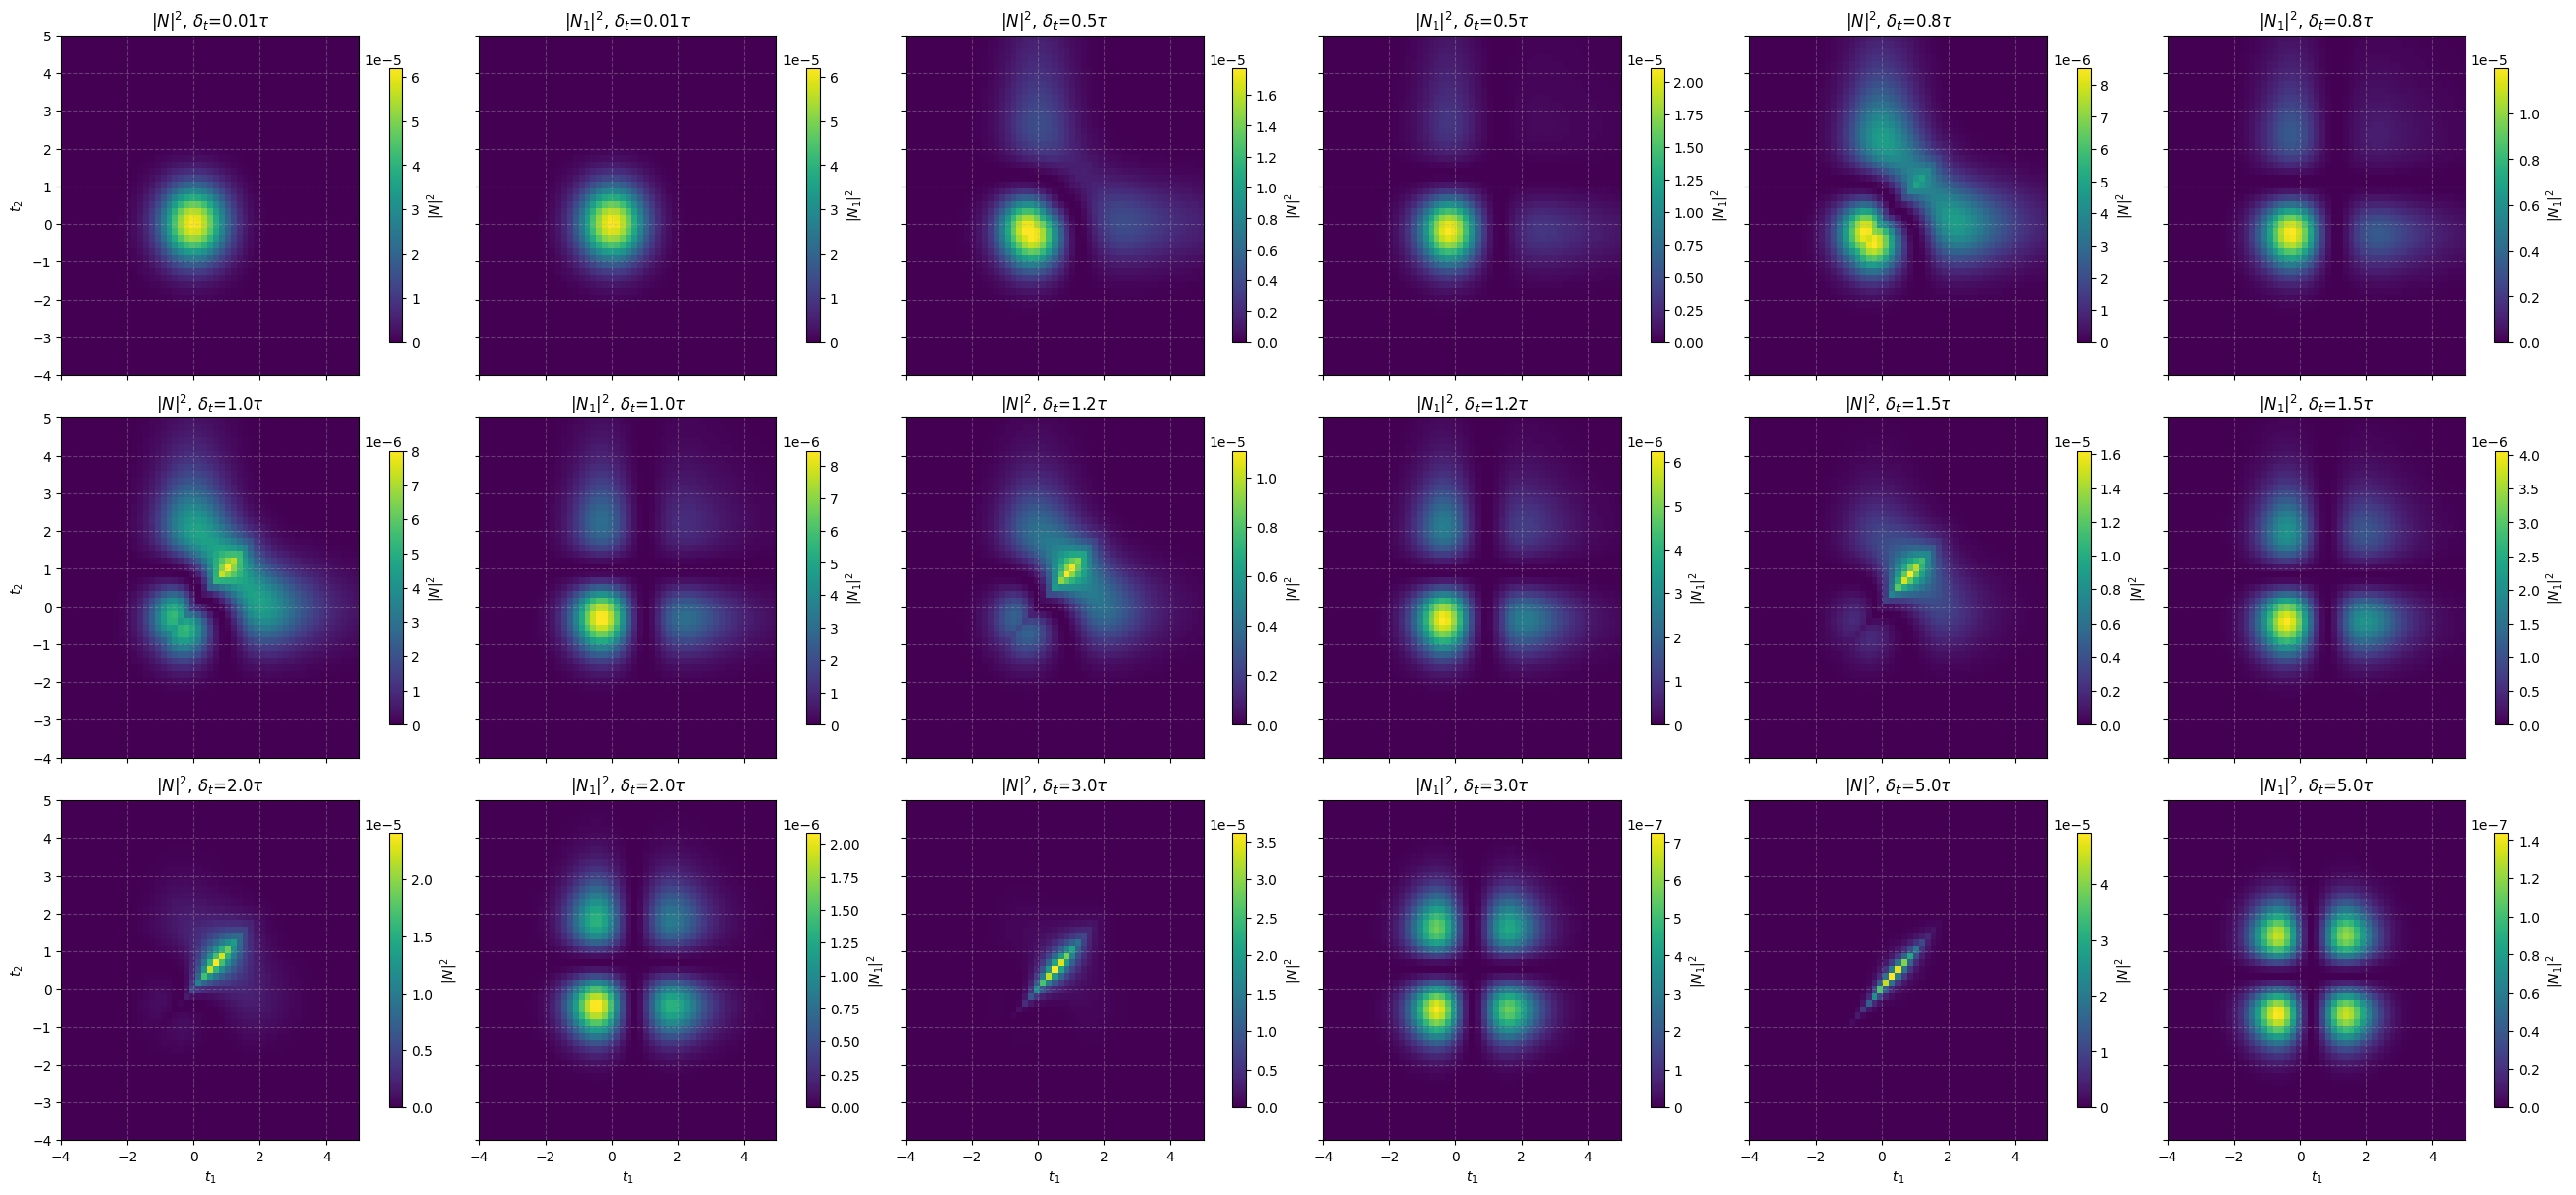

In [19]:
from giant_atom_generate_correlation_function import *
import time 
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
from functools import lru_cache
# Physical / spectral parameters (edit as needed)
# mu        = 3.0     # \bar{ω}
# tau       = 0.229   # 寿命为0.229ns
# delta_t   = 3 * tau     #
# sigma     = 1/delta_t     # spectral width,即波的长度，delta_t
beta      = 1.0 #理想情况下取beta=1，Gamma0=0
# gamma_tot = 1/tau 
Gamma0    = 0.0
omega0    = 5.8
mu        = omega0    # \bar{ω}
Np1       = 2
Np2       = 2
T1        = 0
T2        = 0
# wmax      = 40 * sigma #积分区域的偏置
# g1 = 1.0/mp.sqrt(mp.pi * tau) /4    # 也可以是复数，如 0.1 + 0.02j
# g2 = 1.0/mp.sqrt(mp.pi * tau) /4     # 1/mp.sqrt(mp.pi * tau) /4这个值对应于小原子的情况
# phi0 = 2/mp.pi #相位
test_direction1 = 't'#r反射，t透射;即r对应左侧输出， t对应右侧输出
test_direction2 = 't'



# g1    = mp.mpc(g1)
# g2    = mp.mpc(g2)
# Delta = mp.mpf(Delta)
# phi0  = mp.mpf(phi0)
# Build ψ^(2) with the above parameters
# psi2 = make_psi2(mu, sigma, beta, gamma_tot, Gamma0,omega0,
#                     use_infinite_limits=False, L=wmax)
use_infinite_limits=True

# ========== t1,t2 网格 ==========
t1_min, t1_max, n_t1 = -4,5, 51
t2_min, t2_max, n_t2 = -4,5, 51
t1_vals = np.linspace(t1_min, t1_max, n_t1)
t2_vals = np.linspace(t2_min, t2_max, n_t2)

# ========== 计算 |N| (也可改为实部或模方，见下方注释) ==========
Z_Nval = np.empty((n_t2, n_t1), dtype=float)  # 行对应 t2，列对应 t1
Z_Nval1 = np.empty((n_t2, n_t1), dtype=complex)  # 行对应 t2，列对应 t1
Z_Nval2 = np.empty((n_t2, n_t1), dtype=complex)  # 行对应 t2，列对应 t1

# ====== 先计算并存储 12 组结果 ======
Z_Nval_allrr  = []
Z_Nval1_allrr = []
Z_Nval2_allrr = []
phi_list = []
ratio = [0.1,0.5,0.8,1,1.2,1.5,2.0,3.0,5]
# matrix = [0.025,0.05,0.1,0.5] 

magnifucation = ratio
for k in range(9):
    T1 =  0  #积分区域的偏置
    T2 =  0
    Np1       = 1
    Np2       = 1
    # phi0 = (k+1) * mp.pi/6
    # delta_t =matrix[k] * tau
    phi0 = mp.pi/2
    tau       = delta_t/(ratio[k])  # 寿命为0.229ns
    # delta_t   = 1 * tau     #
    delta_t = 1e2 # 时域展宽
    sigma     = 1/delta_t     # spectral width,即波的长度，delta_t
    wmax = 40 * sigma
    g1 = 1.0/(mp.sqrt(2 * mp.pi * tau) * 2 * (1+mp.cos(phi0)))    # 也可以是复数，如 0.1 + 0.02j
    g2 = 1.0/(mp.sqrt(2 * mp.pi * tau) * 2 * (1+mp.cos(phi0)))     # 1/mp.sqrt(mp.pi * tau) /4这个值对应于小原子的情况
    Delta = - 4 * mp.pi * mp.re(g1 * mp.conj(g2)) * mp.sin(phi0)
    # g1     = matrix[k] /2 
    # g2     = matrix[k] /2 
    phi_list.append(float(phi0))

    psi2 = make_psi2(mu, sigma,
                     Delta, g1, g2, phi0, omega0,
                     use_infinite_limits=True, L=wmax)

    Z_Nval  = np.empty((n_t2, n_t1), dtype=float)
    Z_Nval1 = np.empty((n_t2, n_t1), dtype=complex)
    Z_Nval2 = np.empty((n_t2, n_t1), dtype=complex)

    for j, t2 in enumerate(t2_vals):
        for i, t1 in enumerate(t1_vals):
            start_time = time.time()

            Nval1 = psi2(t1 * delta_t, t2 * delta_t, T1, Np1, T2, Np2,
                         test_direction1, test_direction2)

            Nval2 = N_of_t(t1 * delta_t, t2 * delta_t, mu, sigma,
                           Delta, g1, g2, phi0, omega0, T1, Np1, T2, Np2,
                           test_direction1, test_direction2,
                           use_infinite_limits=True, wmax=wmax)

            # 你的调试输出保留（不需要可删）
            # print(time.time() - start_time)
            # print(Nval1, Nval2)

            Z_Nval1[j, i] = complex(Nval1)
            Z_Nval2[j, i] = complex(Nval2)

            Nc = complex(Nval1) + complex(Nval2)
            Z_Nval[j, i] = abs(Nc) ** 2

    Z_Nval_allrr.append(Z_Nval)
    Z_Nval1_allrr.append(Z_Nval1)
    Z_Nval2_allrr.append(Z_Nval2)
    magnifucation[k] = delta_t/tau

# ====== 统一色标范围（可选但推荐：让不同 k 的图可比）======
vmax_N  = max(Z.max() for Z in Z_Nval_allrr)
vmax_N1 = max((np.abs(Z1) ** 2).max() for Z1 in Z_Nval1_allrr)

# ====== 一次性画成 4 行 6 列（24 子图）======
# ====== 一次性画成 4 行 6 列（24 子图），且每个子图各自一条 colorbar ======
# （建议用 constrained_layout=True，避免 tight_layout 和大量 colorbar 冲突）
fig, axs = plt.subplots(
    3, 6, figsize=(26, 12),
    sharex=True, sharey=True,
    constrained_layout=True
)
cmap = plt.cm.Reds.copy()
for k in range(9):
    r = k // 3            # 0..3
    c = 2 * (k % 3)         # 0,2,4 (每个 k 占两列)

    axL = axs[r, c]
    axR = axs[r, c + 1]

    ZL = Z_Nval_allrr[k]
    ZR = np.abs(Z_Nval1_allrr[k]) ** 2

    # ====== 如果你仍想让所有子图同一色标范围（便于比较），取消注释下面两行 ======
    # imL = axL.imshow(ZL, extent=[t1_min, t1_max, t2_min, t2_max], origin='lower', aspect='auto', vmin=0, vmax=vmax_N)
    # imR = axR.imshow(ZR, extent=[t1_min, t1_max, t2_min, t2_max], origin='lower', aspect='auto', vmin=0, vmax=vmax_N1)

    # ====== 如果你希望每张图按自身范围拉伸（更清晰），用下面这两行（默认推荐）======
    imL = axL.imshow(
        ZL, extent=[t1_min, t1_max, t2_min, t2_max],
        origin='lower', aspect='auto'
    )
    imR = axR.imshow(
        ZR, extent=[t1_min, t1_max, t2_min, t2_max],
        origin='lower', aspect='auto'
    )

    axL.set_title(rf'$|N|^2$, $\delta_t$={ratio[k]}$\tau$')
    axR.set_title(rf'$|N_1|^2$, $\delta_t$={ratio[k]}$\tau$')

    axL.grid(ls='--', alpha=0.35)
    axR.grid(ls='--', alpha=0.35)

    # ====== 关键：每个子图各自加 colorbar ======
    cbL = fig.colorbar(imL, ax=axL, fraction=0.046, pad=0.02)
    cbL.set_label(r'$|N|^2$')
    cbR = fig.colorbar(imR, ax=axR, fraction=0.046, pad=0.02)
    cbR.set_label(r'$|N_1|^2$')

# 只给最左列标 y、最下行标 x（避免太挤）
for rr in range(3):
    axs[rr, 0].set_ylabel(r'$t_2$')
for cc in range(6):
    axs[2, cc].set_xlabel(r'$t_1$')

plt.show()




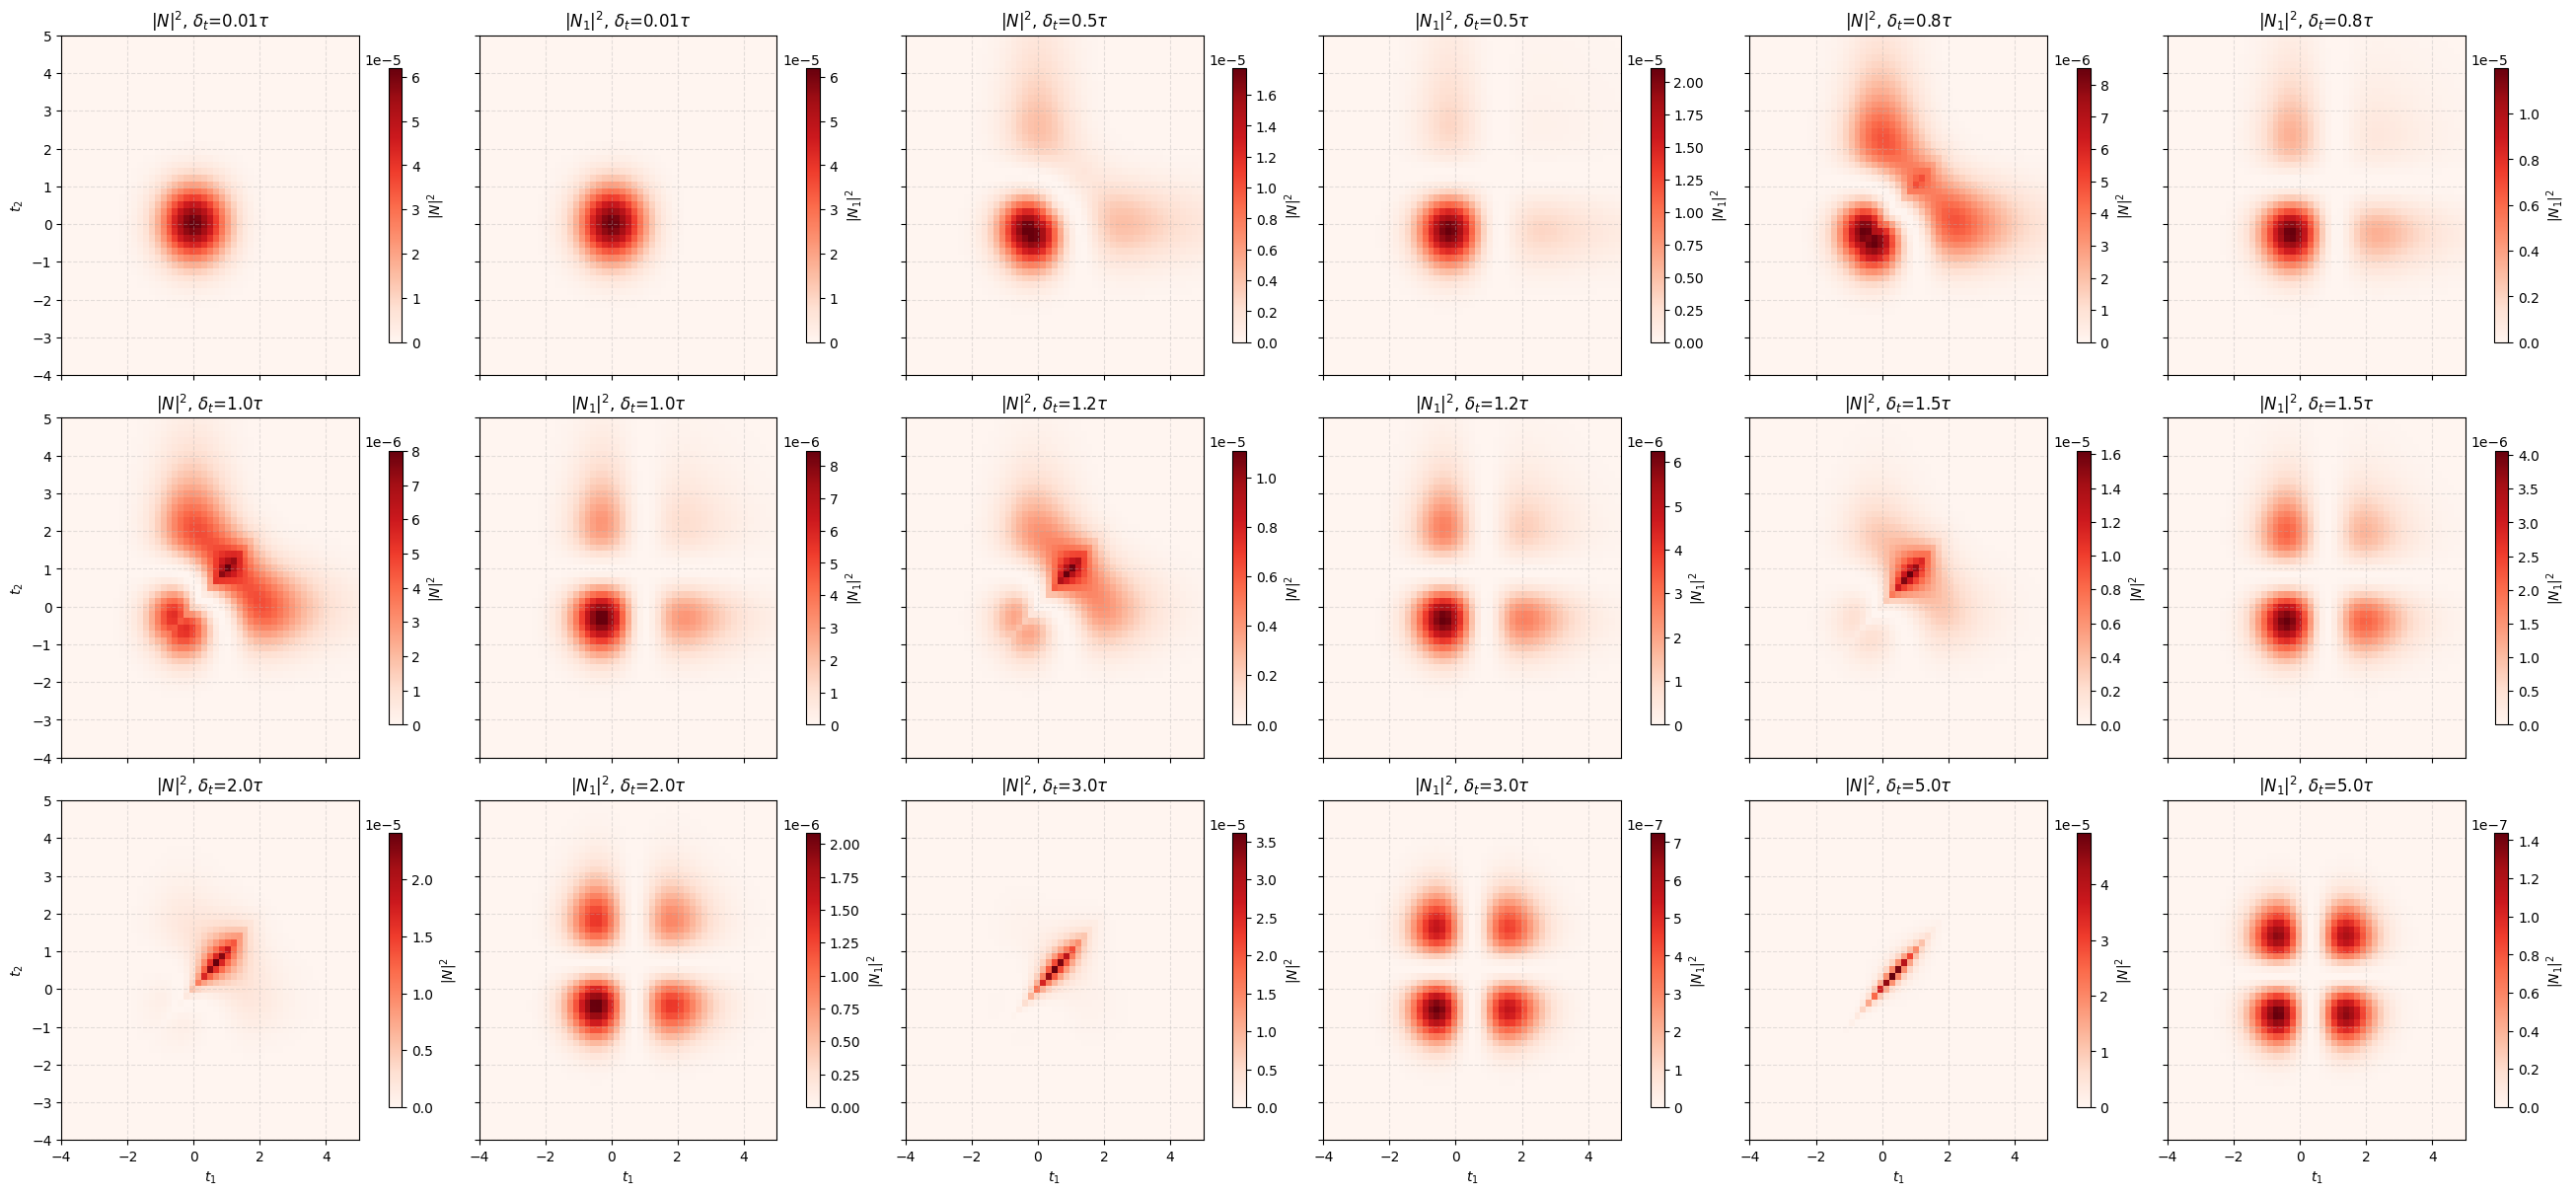

In [20]:
fig, axs = plt.subplots(
    3, 6, figsize=(26, 12),
    sharex=True, sharey=True,
    constrained_layout=True
)
cmap = plt.cm.Reds.copy()
for k in range(9):
    r = k // 3            # 0..3
    c = 2 * (k % 3)         # 0,2,4 (每个 k 占两列)

    axL = axs[r, c]
    axR = axs[r, c + 1]

    ZL = Z_Nval_allrr[k]
    ZR = np.abs(Z_Nval1_allrr[k]) ** 2

    # ====== 如果你仍想让所有子图同一色标范围（便于比较），取消注释下面两行 ======
    # imL = axL.imshow(ZL, extent=[t1_min, t1_max, t2_min, t2_max], origin='lower', aspect='auto', vmin=0, vmax=vmax_N)
    # imR = axR.imshow(ZR, extent=[t1_min, t1_max, t2_min, t2_max], origin='lower', aspect='auto', vmin=0, vmax=vmax_N1)

    # ====== 如果你希望每张图按自身范围拉伸（更清晰），用下面这两行（默认推荐）======
    imL = axL.imshow(
        ZL, extent=[t1_min, t1_max, t2_min, t2_max],
        origin='lower', aspect='auto',cmap=cmap 
    )
    imR = axR.imshow(
        ZR, extent=[t1_min, t1_max, t2_min, t2_max],
        origin='lower', aspect='auto',cmap=cmap
    )

    axL.set_title(rf'$|N|^2$, $\delta_t$={ratio[k]}$\tau$')
    axR.set_title(rf'$|N_1|^2$, $\delta_t$={ratio[k]}$\tau$')

    axL.grid(ls='--', alpha=0.35)
    axR.grid(ls='--', alpha=0.35)

    # ====== 关键：每个子图各自加 colorbar ======
    cbL = fig.colorbar(imL, ax=axL, fraction=0.046, pad=0.02)
    cbL.set_label(r'$|N|^2$')
    cbR = fig.colorbar(imR, ax=axR, fraction=0.046, pad=0.02)
    cbR.set_label(r'$|N_1|^2$')

# 只给最左列标 y、最下行标 x（避免太挤）
for rr in range(3):
    axs[rr, 0].set_ylabel(r'$t_2$')
for cc in range(6):
    axs[2, cc].set_xlabel(r'$t_1$')

plt.show()



## 改变输入波展宽

# 实验二

## 第一张用于示意的图

In [15]:
from giant_atom_generate_correlation_function import *
import time 
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
from functools import lru_cache
import json
# Physical / spectral parameters (edit as needed)
# mu        = 3.0     # \bar{ω}
# tau       = 0.229   # 寿命为0.229ns
# delta_t   = 3 * tau     #
# sigma     = 1/delta_t     # spectral width,即波的长度，delta_t
beta      = 1.0 #理想情况下取beta=1，Gamma0=0
# gamma_tot = 1/tau 
Gamma0    = 0.0
omega0    = 5.8
mu        = omega0    # \bar{ω}
Np1       = 1
Np2       = 1
T1        = 0
T2        = 0
# wmax      = 40 * sigma #积分区域的偏置

# g1 = 1.0/mp.sqrt(mp.pi * tau) /4    # 也可以是复数，如 0.1 + 0.02j
# g2 = 1.0/mp.sqrt(mp.pi * tau) /4     # 1/mp.sqrt(mp.pi * tau) /4这个值对应于小原子的情况
# phi0 = 2/mp.pi #相位
test_direction1 = 't'#r反射，t透射;即r对应左侧输出， t对应右侧输出
test_direction2 = 't'
name = 'R2_giant_atom_g1g2_tt_resonance_coupling_ratio=1.0,1.5_test1_v2.npz'

# g1    = mp.mpc(g1)
# g2    = mp.mpc(g2)
# Delta = mp.mpf(Delta)
# phi0  = mp.mpf(phi0)
# Build ψ^(2) with the above parameters
# psi2 = make_psi2(mu, sigma, beta, gamma_tot, Gamma0,omega0,
#                     use_infinite_limits=False, L=wmax)
use_infinite_limits=True

# ========== t1,t2 网格 ==========
t1_min, t1_max, n_t1 = -3,6, 271
t2_min, t2_max, n_t2 = -3,6, 271
t1_vals = np.linspace(t1_min, t1_max, n_t1)
t2_vals = np.linspace(t2_min, t2_max, n_t2)

# ========== 计算 |N| (也可改为实部或模方，见下方注释) ==========
Z_Nval = np.empty((n_t2, n_t1), dtype=float)  # 行对应 t2，列对应 t1
Z_Nval1 = np.empty((n_t2, n_t1), dtype=complex)  # 行对应 t2，列对应 t1
Z_Nval2 = np.empty((n_t2, n_t1), dtype=complex)  # 行对应 t2，列对应 t1

# ====== 先计算并存储 12 组结果 ======
Z_Nval_allrr  = []
Z_Nval1_allrr = []
Z_Nval2_allrr = []
phi_list = []
ratio = [1.0, 1.5] # delta_t/tau，即比例
# ratio = [0.5,0.75] 
# matrix = [0.025,0.05,0.1,0.5] 

# 数据存储初始化
K = len(ratio)
global_params = dict(
    beta=float(beta),
    Gamma0=float(Gamma0),
    omega0=float(omega0),
    mu=float(mu),
    # Delta=float(Delta),
    test_direction1=test_direction1,
    test_direction2=test_direction2,
    use_infinite_limits=bool(use_infinite_limits),
    t1_min=float(t1_min), t1_max=float(t1_max), n_t1=int(n_t1),
    t2_min=float(t2_min), t2_max=float(t2_max), n_t2=int(n_t2),
)

per_k_params = []                 # 每个k的参数字典
magnification = np.empty(K)       # delta_t/tau



magnification = ratio 
for k in range(K):
    # phi0 = (k+1) * mp.pi/6
    # delta_t =matrix[k] * tau
    phi0 =  mp.pi/2
    delta_t = 1e2 # 时域展宽
    tau       = delta_t/(ratio[k])  
    # delta_t   = 1 * tau     #
    sigma     = 1/delta_t     # spectral width,即波的长度，delta_t
    wmax = 40 * sigma
    g1 = 1.0/(mp.sqrt(2 * mp.pi * tau * 2 * (1+mp.cos(phi0))))    # 也可以是复数，如 0.1 + 0.02j
    g2 = 1.0/(mp.sqrt(2 * mp.pi * tau * 2 * (1+mp.cos(phi0))))     # 1/mp.sqrt(mp.pi * tau) /4这个值对应于小原子的情况
    Delta = - 4 * mp.pi * mp.re(g1 * mp.conj(g2)) * mp.sin(phi0)

    # g1     = matrix[k] /2 
    # g2     = matrix[k] /2 
    phi_list.append(float(phi0))

    psi2 = make_psi2(mu, sigma,
                     Delta, g1, g2, phi0, omega0,
                     use_infinite_limits=use_infinite_limits, L=wmax)

    Z_Nval  = np.empty((n_t2, n_t1), dtype=float)
    Z_Nval1 = np.empty((n_t2, n_t1), dtype=complex)
    Z_Nval2 = np.empty((n_t2, n_t1), dtype=complex)

    # 存储每一个循环的数据
    per_k_params.append(dict(
        k=int(k),
        ratio=float(ratio[k]),
        T1=float(T1), T2=float(T2),
        Np1=int(Np1), Np2=int(Np2),
        phi0=float(phi0),
        tau=float(tau),
        delta_t=float(delta_t),
        sigma=float(sigma),
        wmax=float(wmax),
        g1=complex(g1),
        g2=complex(g2),
        Delta = complex(Delta),
    ))

    magnification[k] = float(delta_t / tau)

    for j, t2 in enumerate(t2_vals):
        for i, t1 in enumerate(t1_vals):
            start_time = time.time()

            Nval1 = psi2(t1 * delta_t, t2 * delta_t, T1, Np1, T2, Np2,
                         test_direction1, test_direction2)

            Nval2 = N_of_t(t1 * delta_t, t2 * delta_t, mu, sigma,
                           Delta, g1, g2, phi0, omega0, T1, Np1, T2, Np2,
                           test_direction1, test_direction2,
                           use_infinite_limits=use_infinite_limits, wmax=wmax)

            # 你的调试输出保留（不需要可删）
            # print(time.time() - start_time)
            # print(Nval1, Nval2)

            Z_Nval1[j, i] = complex(Nval1)
            Z_Nval2[j, i] = complex(Nval2)

            Nc = complex(Nval1) + complex(Nval2)
            Z_Nval[j, i] = abs(Nc) ** 2

    Z_Nval_allrr.append(Z_Nval)
    Z_Nval1_allrr.append(Z_Nval1)
    Z_Nval2_allrr.append(Z_Nval2)
    magnification[k] = delta_t/tau

# 数据存储
# 3D: (K, n_t2, n_t1)
Nval1_all = np.stack(Z_Nval1_allrr, axis=0).astype(np.complex128)
Nval2_all = np.stack(Z_Nval2_allrr, axis=0).astype(np.complex128)
Nc_abs2_all = np.stack(Z_Nval_allrr, axis=0).astype(np.float64)

np.savez_compressed(
    name,
    global_params=np.array([global_params], dtype=object),
    per_k_params=np.array(per_k_params, dtype=object),
    t1_vals=t1_vals,
    t2_vals=t2_vals,
    ratio=np.array(ratio, dtype=float),
    magnification=magnification,
    Nval1=Nval1_all,
    Nval2=Nval2_all,
    Nc_abs2=Nc_abs2_all,
)

# # 可选：单独存一个纯文本参数文件（更好读）
# with open("giant_atom_corr_params.json", "w", encoding="utf-8") as f:
#     json.dump(
#         {"global_params": global_params, "per_k_params": per_k_params},
#         f, ensure_ascii=False, indent=2,
#         default=lambda o: str(o)  # 避免 mp 类型报错
#     )

print("Saved: {name}")





Saved: {name}


In [21]:
import numpy as np
from pprint import pprint
d = np.load("/home/yyj/Projects/WQED/R1_giant_atom_g1g2_tt_resonance_coupling_test1.npz", allow_pickle=True)
global_params = d["global_params"].item()
per_k_params = d["per_k_params"].tolist()

t1_vals = d["t1_vals"]
t1_vals = d["t1_vals"]
t2_vals = d["t2_vals"]
Nval1 = d["Nval1"]   # shape: (K, n_t2, n_t1)
Nval2 = d["Nval2"]
Nc_abs2 = d["Nc_abs2"]
ratio = d["ratio"]
t1_min = global_params["t1_min"]
t1_max = global_params["t1_max"]
n_t1 = global_params["n_t1"]
t2_min = global_params["t2_min"]  
t2_max = global_params["t2_max"]
n_t2 = global_params["n_t2"]
# 例如：取第k组、t2第j点、t1第i点：
# Nval1[k,j,i], Nval2[k,j,i]
pprint(global_params, sort_dicts=False)   # 全局参数多行展示
pprint(t1_vals, sort_dicts=False)   # 全局参数多行展示
pprint(t2_vals, sort_dicts=False)   # 全局参数多行展示
print("\nper_k_params:")
for item in per_k_params:
    pprint(item, sort_dicts=False)
    print("-" * 60)

{'beta': 1.0,
 'Gamma0': 0.0,
 'omega0': 5.8,
 'mu': 5.8,
 'test_direction1': 't',
 'test_direction2': 't',
 'use_infinite_limits': True,
 't1_min': -4.0,
 't1_max': 5.0,
 'n_t1': 271,
 't2_min': -4.0,
 't2_max': 5.0,
 'n_t2': 271}
array([-4.        , -3.96666667, -3.93333333, -3.9       , -3.86666667,
       -3.83333333, -3.8       , -3.76666667, -3.73333333, -3.7       ,
       -3.66666667, -3.63333333, -3.6       , -3.56666667, -3.53333333,
       -3.5       , -3.46666667, -3.43333333, -3.4       , -3.36666667,
       -3.33333333, -3.3       , -3.26666667, -3.23333333, -3.2       ,
       -3.16666667, -3.13333333, -3.1       , -3.06666667, -3.03333333,
       -3.        , -2.96666667, -2.93333333, -2.9       , -2.86666667,
       -2.83333333, -2.8       , -2.76666667, -2.73333333, -2.7       ,
       -2.66666667, -2.63333333, -2.6       , -2.56666667, -2.53333333,
       -2.5       , -2.46666667, -2.43333333, -2.4       , -2.36666667,
       -2.33333333, -2.3       , -2.26666667, -2

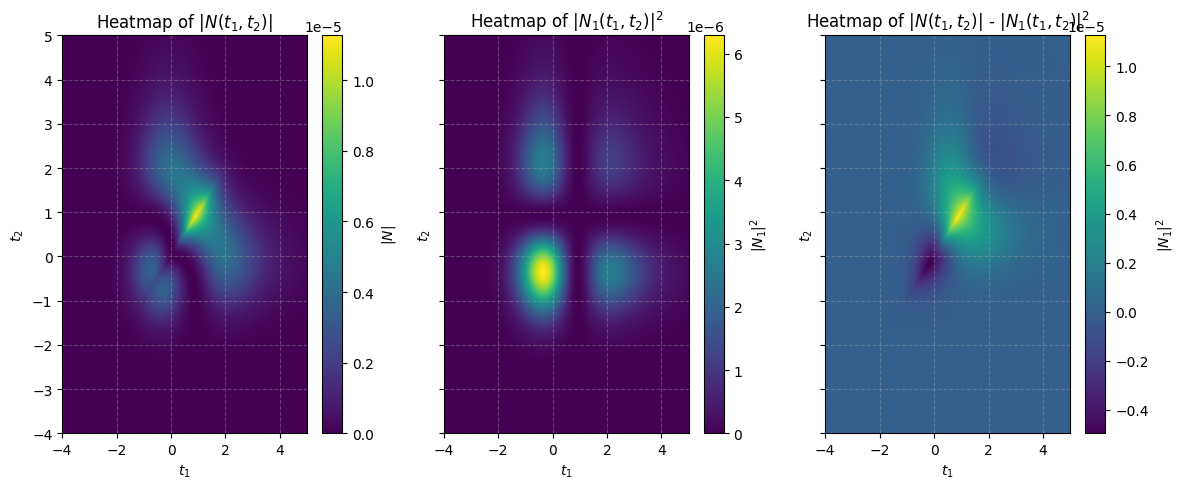

In [22]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 3, figsize=(12, 5), sharex=True, sharey=True)

n = 4

def show_heat(ax, Z, title, cbar_label):
    im = ax.imshow(
        Z, extent=[t1_min, t1_max, t2_min, t2_max],
        origin='lower', aspect='auto'
    )
    ax.set_xlabel(r'$t_1$')
    ax.set_ylabel(r'$t_2$')
    ax.set_title(title)
    ax.grid(ls='--', alpha=0.35)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)
    return im

Z_Nval = abs(Nval1 + Nval2)**2  # 计算 |N|^2
# 左图：原本的 |N|
show_heat(axs[0], Z_Nval[n], r'Heatmap of $|N(t_1,t_2)|$', r'$|N|$')

# 右图：示例显示第二个矩阵（这里用 Z_Nval1 的模方；没有就换成你的另一幅矩阵）
Z_right = abs(Nval1[n])**2  # 如果你想显示别的，替换这行
show_heat(axs[1], Z_right, r'Heatmap of $|N_1(t_1,t_2)|^2$', r'$|N_1|^2$')

# Z_right = abs(Z_Nval1)**2  # 如果你想显示别的，替换这行
show_heat(axs[2], Z_Nval[n] - Z_right, r'Heatmap of $|N(t_1,t_2)|$ - $|N_1(t_1,t_2)|^2$', r'$|N_1|^2$')
plt.tight_layout()
plt.show()

## 第二张用于比较的图

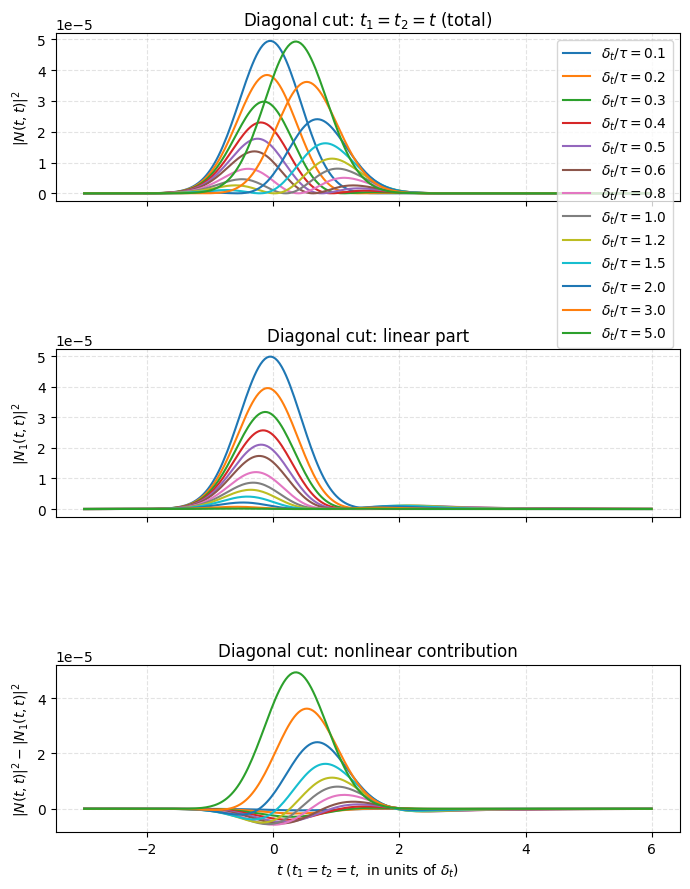

[saved] R2_giant_atom_g1g2_tt_resonance_lines_ratios_test1_v2.npz


In [16]:
from giant_atom_generate_correlation_function import *
import time
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp

# ===================== 固定参数（按你原来的） =====================
# tau       = 0.229   # ns
omega0    = 5.8
mu        = omega0
# Delta     = 0

# g1 = 1.0/mp.sqrt(mp.pi * tau) / 4
# g2 = 1.0/mp.sqrt(mp.pi * tau) / 4
phi0 = 1 * mp.pi / 2

test_direction1 = 't'
test_direction2 = 't'

T1, T2 = 0, 0
Np1, Np2 = 1, 1
use_infinite_limits = True
save_path = "R2_giant_atom_g1g2_tt_resonance_lines_ratios_test1_v2.npz"

# mpmath 类型
# g1    = mp.mpc(g1)
# g2    = mp.mpc(g2)
# Delta = mp.mpf(Delta)
# phi0  = mp.mpf(phi0)

# ===================== 你要比较的比例：delta_t / tau =====================
ratios = [0.1,0.2,0.3,0.4,0.5,0.6,0.8, 1.0, 1.2, 1.5,2.0,3.0,5.0]
# ratios = [0.05,0.1,0.15,0.2,0.25,0.3,0.4,0.5, 0.6, 0.75,1.0,1.5,2.5]
# ratios = [3]
# ratios = [0.8, 1.0, 1.2]
# ===================== 对角线参数：t1=t2=t =====================
# 这里 t 代表 “以 delta_t 归一化后的时间”，真正传进函数的是 t*delta_t（单位 ns）
t_min, t_max, n_t = -3, 6, 271
t_diag = np.linspace(t_min, t_max, n_t)

# 保存不同ratio下的一维线
lines_total = {}   # |N(t,t)|^2
lines_lin   = {}   # |N1(t,t)|^2
lines_nl    = {}   # |N|^2 - |N1|^2

for r in ratios:
    delta_t = 1e2
    tau     = delta_t/r
    sigma   = 1.0 / delta_t
    wmax    = 40 * sigma
    g1 = 1.0/(mp.sqrt(2 * mp.pi * tau * 4 * (1+mp.cos(phi0))))    # 也可以是复数，如 0.1 + 0.02j
    g2 = 1.0/(mp.sqrt(2 * mp.pi * tau * 4 * (1+mp.cos(phi0))))     # 1/mp.sqrt(mp.pi * tau) /4这个值对应于小原子的情况
    Delta = - 4 * mp.pi * mp.re(g1 * mp.conj(g2)) * mp.sin(phi0)

    # 构造 psi2（线性/一阶项）
    psi2 = make_psi2(mu, sigma,
                     Delta, g1, g2, phi0, omega0,
                     use_infinite_limits=use_infinite_limits, L=wmax)

    y_total = np.empty_like(t_diag, dtype=float)
    y_lin   = np.empty_like(t_diag, dtype=float)
    y_nl    = np.empty_like(t_diag, dtype=float)

    for idx, t in enumerate(t_diag):
        t1 = t * delta_t
        t2 = t * delta_t  # t1=t2

        # 一阶项
        Nval1 = psi2(t1, t2, T1, Np1, T2, Np2, test_direction1, test_direction2)

        # 二阶非线性项
        Nval2 = N_of_t(t1, t2, mu, sigma,
                       Delta, g1, g2, phi0, omega0,
                       T1, Np1, T2, Np2,
                       test_direction1, test_direction2,
                       use_infinite_limits=use_infinite_limits, wmax=wmax)

        N1 = complex(Nval1)
        N2 = complex(Nval2)
        Nc = N1 + N2

        y_lin[idx]   = abs(N1)**2
        y_total[idx] = abs(Nc)**2
        y_nl[idx]    = y_total[idx] - y_lin[idx]

    lines_total[r] = y_total
    lines_lin[r]   = y_lin
    lines_nl[r]    = y_nl

# ===================== 画图：三张一维线（总/线性/非线性） =====================
fig, axs = plt.subplots(3, 1, figsize=(7, 9), sharex=True)

for r in ratios:
    axs[0].plot(t_diag, lines_total[r], label=fr'$\delta_t/\tau={r}$')
axs[0].set_ylabel(r'$|N(t,t)|^2$')
axs[0].set_title(r'Diagonal cut: $t_1=t_2=t$ (total)')
axs[0].grid(ls='--', alpha=0.35)
axs[0].legend()

for r in ratios:
    axs[1].plot(t_diag, lines_lin[r], label=fr'$\delta_t/\tau={r}$')
axs[1].set_ylabel(r'$|N_1(t,t)|^2$')
axs[1].set_title(r'Diagonal cut: linear part')
axs[1].grid(ls='--', alpha=0.35)

for r in ratios:
    axs[2].plot(t_diag, lines_nl[r], label=fr'$\delta_t/\tau={r}$')
axs[2].set_xlabel(r'$t\ (t_1=t_2=t,\ \mathrm{in\ units\ of}\ \delta_t)$')
axs[2].set_ylabel(r'$|N(t,t)|^2-|N_1(t,t)|^2$')
axs[2].set_title(r'Diagonal cut: nonlinear contribution')
axs[2].grid(ls='--', alpha=0.35)

plt.tight_layout()
plt.show()

# ===================== 数据存储 =====================
# ===================== 保存结果（npz，推荐） =====================
import numpy as np

def stack_lines(lines_dict, ratios):
    """把 dict[ratio] -> 1D array 按 ratios 顺序堆成 2D: (n_ratios, n_t)"""
    return np.stack([np.asarray(lines_dict[r], dtype=float) for r in ratios], axis=0)

# 按 ratios 顺序堆叠
Y_total = stack_lines(lines_total, ratios)  # shape: (len(ratios), n_t)
Y_lin   = stack_lines(lines_lin,   ratios)
Y_nl    = stack_lines(lines_nl,    ratios)

ratios_arr  = np.array(ratios, dtype=float)
tau_f       = float(tau)
delta_t_arr = ratios_arr * tau_f
sigma_arr   = 1.0 / delta_t_arr
wmax_arr    = 20.0 * sigma_arr

# 额外把关键参数也存进去（方便你未来核对/复现）
params = dict(
    tau=tau_f,
    omega0=float(omega0),
    mu=float(mu),
    Delta=float(Delta),
    g1=complex(g1),
    g2=complex(g2),
    phi0=float(phi0),
    T1=int(T1), T2=int(T2),
    Np1=int(Np1), Np2=int(Np2),
    test_direction1=str(test_direction1),
    test_direction2=str(test_direction2),
    use_infinite_limits=bool(use_infinite_limits),
    t_min=float(t_min), t_max=float(t_max), n_t=int(n_t),
)


np.savez_compressed(
    save_path,
    t_diag=np.asarray(t_diag, dtype=float),      # 归一化后的 t（单位：delta_t）
    ratios=ratios_arr,
    delta_t=delta_t_arr,
    sigma=sigma_arr,
    wmax=wmax_arr,
    Y_total=Y_total,
    Y_lin=Y_lin,
    Y_nl=Y_nl,
    params=np.array(params, dtype=object),       # dict 需要 allow_pickle 读取
)

print(f"[saved] {save_path}")





/tmp/ipykernel_3705716/3484555488.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


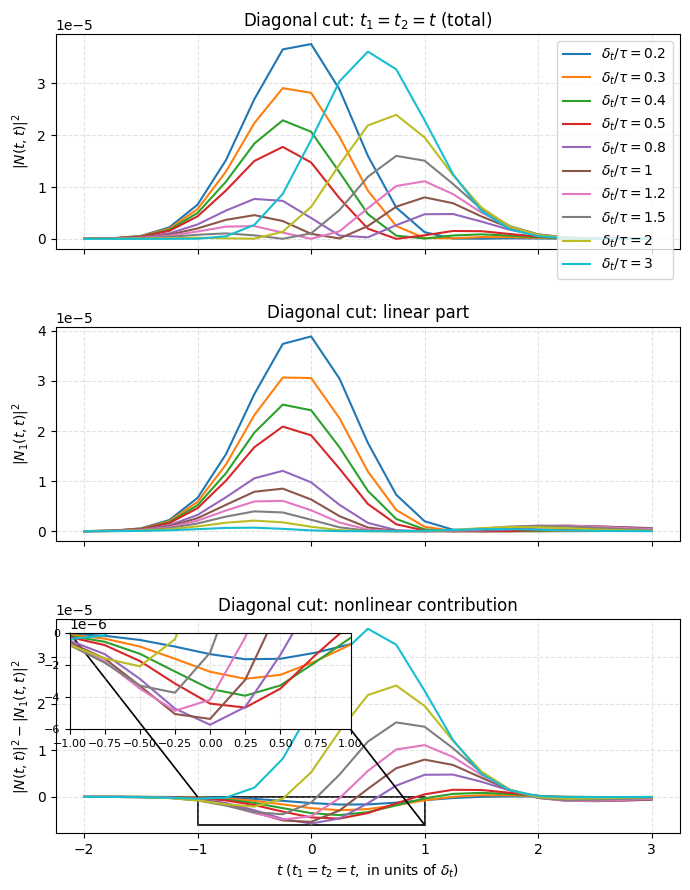

Loaded params: {'tau': 33.333333333333336, 'omega0': 5.8, 'mu': 5.8, 'Delta': -0.015, 'g1': (0.034549414947133546+0j), 'g2': (0.034549414947133546+0j), 'phi0': 1.5707963267948966, 'T1': 0, 'T2': 0, 'Np1': 1, 'Np2': 1, 'test_direction1': 't', 'test_direction2': 't', 'use_infinite_limits': True, 't_min': -2.0, 't_max': 3.0, 'n_t': 21}


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

load_path = "diag_cut_results.npz"
data = np.load(load_path, allow_pickle=True)

t_diag  = data["t_diag"]
ratios  = data["ratios"]
Y_total = data["Y_total"]
Y_lin   = data["Y_lin"]
Y_nl    = data["Y_nl"]
params  = data["params"].item()   # 还原成 dict

# ===================== 重新画三张图 =====================
fig, axs = plt.subplots(3, 1, figsize=(7, 9), sharex=True)

for i, r in enumerate(ratios):
    axs[0].plot(t_diag, Y_total[i], label=fr'$\delta_t/\tau={r:g}$')
axs[0].set_ylabel(r'$|N(t,t)|^2$')
axs[0].set_title(r'Diagonal cut: $t_1=t_2=t$ (total)')
axs[0].grid(ls='--', alpha=0.35)
axs[0].legend()

for i, r in enumerate(ratios):
    axs[1].plot(t_diag, Y_lin[i], label=fr'$\delta_t/\tau={r:g}$')
axs[1].set_ylabel(r'$|N_1(t,t)|^2$')
axs[1].set_title(r'Diagonal cut: linear part')
axs[1].grid(ls='--', alpha=0.35)

for i, r in enumerate(ratios):
    axs[2].plot(t_diag, Y_nl[i], label=fr'$\delta_t/\tau={r:g}$')
axs[2].set_xlabel(r'$t\ (t_1=t_2=t,\ \mathrm{in\ units\ of}\ \delta_t)$')
axs[2].set_ylabel(r'$|N(t,t)|^2-|N_1(t,t)|^2$')
axs[2].set_title(r'Diagonal cut: nonlinear contribution')
axs[2].grid(ls='--', alpha=0.35)

# 绘制小图
# ====== 在最后一张图上：框选 x∈[-1,1] 且 y<0 的区域，并在左上角做放大 inset ======
x1, x2 = -1.0, 1.0

# 找到 x 在 [-1,1] 的点
mask = (t_diag >= x1) & (t_diag <= x2)

# 取所有 ratio 在该区间内的最小值（最负的值），上边界固定到 0（只看 y<0）
y_min = np.min(Y_nl[:, mask])
y_max = 0.0

# 给一点边距（让框别贴着曲线）
y_min_zoom = y_min * 1.05 if y_min < 0 else -1e-12
y_max_zoom = y_max

# 1) 创建 inset 小图：放在左上角
axins = inset_axes(
    axs[2],
    width="45%", height="45%",     # 小图大小，可改 "40%" "50%" 等
    loc="upper left",
    borderpad=1.0
)

# 2) 在 inset 里重画同样的曲线（只放大显示）
for i, r in enumerate(ratios):
    axins.plot(t_diag, Y_nl[i])

axins.set_xlim(x1, x2)
axins.set_ylim(y_min_zoom, y_max_zoom)
axins.grid(ls='--', alpha=0.35)
axins.tick_params(labelsize=8)

# 3) 在主图上画框，并用连线标出对应区域
mark_inset(axs[2], axins, loc1=2, loc2=4, fc="none", ec="black", lw=1.2)


plt.tight_layout()
plt.show()

print("Loaded params:", params)


# 实验三

## 2*2组图部分

In [17]:
from giant_atom_generate_correlation_function import *
import time 
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
from functools import lru_cache
import json
# Physical / spectral parameters (edit as needed)
# mu        = 3.0     # \bar{ω}
# tau       = 0.229   # 寿命为0.229ns
# delta_t   = 3 * tau     #
# sigma     = 1/delta_t     # spectral width,即波的长度，delta_t
beta      = 1.0 #理想情况下取beta=1，Gamma0=0
# gamma_tot = 1/tau 
Gamma0    = 0.0
omega0    = 5.8
mu        = omega0    # \bar{ω}
Np1       = 1
Np2       = 1
T1        = 0
T2        = 0
ratio = 3
# wmax      = 40 * sigma #积分区域的偏置

# g1 = 1.0/mp.sqrt(mp.pi * tau) /4    # 也可以是复数，如 0.1 + 0.02j
# g2 = 1.0/mp.sqrt(mp.pi * tau) /4     # 1/mp.sqrt(mp.pi * tau) /4这个值对应于小原子的情况
# phi0 = 2/mp.pi #相位
test_direction1 = 't'#r反射，t透射;即r对应左侧输出， t对应右侧输出
test_direction2 = 't'
name = 'R3_giant_atom_g1g2_tt_phase_Sectional_test1_v2.npz'

# g1    = mp.mpc(g1)
# g2    = mp.mpc(g2)
# Delta = mp.mpf(Delta)
# phi0  = mp.mpf(phi0)
# Build ψ^(2) with the above parameters
# psi2 = make_psi2(mu, sigma, beta, gamma_tot, Gamma0,omega0,
#                     use_infinite_limits=False, L=wmax)
use_infinite_limits=True

# ========== t1,t2 网格 ==========
t1_min, t1_max, n_t1 = -3,6, 271
t2_min, t2_max, n_t2 = -3,6, 271
t1_vals = np.linspace(t1_min, t1_max, n_t1)
t2_vals = np.linspace(t2_min, t2_max, n_t2)

# ========== 计算 |N| (也可改为实部或模方，见下方注释) ==========
Z_Nval = np.empty((n_t2, n_t1), dtype=float)  # 行对应 t2，列对应 t1
Z_Nval1 = np.empty((n_t2, n_t1), dtype=complex)  # 行对应 t2，列对应 t1
Z_Nval2 = np.empty((n_t2, n_t1), dtype=complex)  # 行对应 t2，列对应 t1

# ====== 先计算并存储 12 组结果 ======
Z_Nval_allrr  = []
Z_Nval1_allrr = []
Z_Nval2_allrr = []
phi_list = []
# ratio = [0.1,0.5,0.8,1,1.2,1.5,2.0,3.0,5.0] # delta_t/tau，即比例
# matrix = [0.025,0.05,0.1,0.5] 

# 数据存储初始化
K = 12
global_params = dict(
    beta=float(beta),
    Gamma0=float(Gamma0),
    omega0=float(omega0),
    mu=float(mu),
    # Delta=float(Delta),
    test_direction1=test_direction1,
    test_direction2=test_direction2,
    use_infinite_limits=bool(use_infinite_limits),
    t1_min=float(t1_min), t1_max=float(t1_max), n_t1=int(n_t1),
    t2_min=float(t2_min), t2_max=float(t2_max), n_t2=int(n_t2),
)

per_k_params = []                 # 每个k的参数字典

for k in range(K):
    # phi0 = (k+1) * mp.pi/6
    # delta_t =matrix[k] * tau
    phi0 =  (k + 1) * mp.pi / 6
    delta_t = 1e2 # 时域展宽
    tau       = delta_t/(ratio)  
    # delta_t   = 1 * tau     #
    sigma     = 1/delta_t     # spectral width,即波的长度，delta_t
    wmax = 40 * sigma
    g1 = 1.0/(mp.sqrt(mp.pi * tau) * 4 )    # 这里我们采用寿命对应与\phi=0时的耦合强度，因为phi=\pi时,耦合强度是发散的。
    g2 = 1.0/(mp.sqrt(mp.pi * tau) * 4 )    
    Delta = - 4 * mp.pi * mp.re(g1 * mp.conj(g2)) * mp.sin(phi0)

    # g1     = matrix[k] /2 
    # g2     = matrix[k] /2 
    phi_list.append(float(phi0))

    psi2 = make_psi2(mu, sigma,
                     Delta, g1, g2, phi0, omega0,
                     use_infinite_limits=use_infinite_limits, L=wmax)

    Z_Nval  = np.empty((n_t2, n_t1), dtype=float)
    Z_Nval1 = np.empty((n_t2, n_t1), dtype=complex)
    Z_Nval2 = np.empty((n_t2, n_t1), dtype=complex)

    # 存储每一个循环的数据
    per_k_params.append(dict(
        k=int(k),
        T1=float(T1), T2=float(T2),
        Np1=int(Np1), Np2=int(Np2),
        phi0=float(phi0),
        tau=float(tau),
        delta_t=float(delta_t),
        sigma=float(sigma),
        wmax=float(wmax),
        g1=complex(g1),
        g2=complex(g2),
        Delta = complex(Delta),
    ))

    # magnification[k] = float(delta_t / tau)

    for j, t2 in enumerate(t2_vals):
        for i, t1 in enumerate(t1_vals):
            start_time = time.time()

            Nval1 = psi2(t1 * delta_t, t2 * delta_t, T1, Np1, T2, Np2,
                         test_direction1, test_direction2)

            Nval2 = N_of_t(t1 * delta_t, t2 * delta_t, mu, sigma,
                           Delta, g1, g2, phi0, omega0, T1, Np1, T2, Np2,
                           test_direction1, test_direction2,
                           use_infinite_limits=use_infinite_limits, wmax=wmax)

            # 你的调试输出保留（不需要可删）
            # print(time.time() - start_time)
            # print(Nval1, Nval2)

            Z_Nval1[j, i] = complex(Nval1)
            Z_Nval2[j, i] = complex(Nval2)

            Nc = complex(Nval1) + complex(Nval2)
            Z_Nval[j, i] = abs(Nc) ** 2

    Z_Nval_allrr.append(Z_Nval)
    Z_Nval1_allrr.append(Z_Nval1)
    Z_Nval2_allrr.append(Z_Nval2)
    # magnification[k] = delta_t/tau

# 数据存储
# 3D: (K, n_t2, n_t1)
Nval1_all = np.stack(Z_Nval1_allrr, axis=0).astype(np.complex128)
Nval2_all = np.stack(Z_Nval2_allrr, axis=0).astype(np.complex128)
Nc_abs2_all = np.stack(Z_Nval_allrr, axis=0).astype(np.float64)
phi_list = np.array(phi_list,dtype=float)
np.savez_compressed(
    name,
    global_params=np.array([global_params], dtype=object),
    per_k_params=np.array(per_k_params, dtype=object),
    t1_vals=t1_vals,
    t2_vals=t2_vals,
    phi_list=phi_list,
    magnification=magnification,
    Nval1=Nval1_all,
    Nval2=Nval2_all,
    Nc_abs2=Nc_abs2_all,
)

# # 可选：单独存一个纯文本参数文件（更好读）
# with open("giant_atom_corr_params.json", "w", encoding="utf-8") as f:
#     json.dump(
#         {"global_params": global_params, "per_k_params": per_k_params},
#         f, ensure_ascii=False, indent=2,
#         default=lambda o: str(o)  # 避免 mp 类型报错
#     )

print("Saved: {name}")





Saved: {name}


## 中间和后面那个图

In [12]:
from giant_atom_generate_correlation_function import *
def make_psi21(t1, t2, T1, Np1, T2, Np2, test_direction1,test_direction2,
              mu, sigma, 
              Delta, g1, g2, phi0, omega0,
            #   reflect_transmission_direction='t',input_driection='right',
              use_infinite_limits=False, L=100):
    """
    Returns a function psi2(t, tau, use_t_left, use_t_right)
    - mu, sigma: Gaussian center and width for f
    - beta, gamma_tot, omega0: parameters for r(ω), t(ω)
    - use_infinite_limits: if True integrate on (-∞,∞); else integrate on [mu-Lσ, mu+Lσ]
    - L: cutoff in units of sigma for finite-range integration
    """
    # mu   = mp.mpf(mu)
    # sigma = mp.mpf(sigma)
    # beta  = mp.mpf(beta)
    # gamma_tot = mp.mpf(gamma_tot)
    # omega0 = mp.mpf(omega0)

    # One-dimensional integral，定义待积分函数
    def I_of_x(x,T,Np,reflect_transmission_direction,input_driection):
        """I(x) = ∫ f(ω) χ(ω) e^{-i ω x} dω.""" #chi(k, Delta, g1, g2, phi0, reflect_transmission_direction='t',inmput_driection='right')
        def integrand(omega):
            return f_gauss(omega , mu, sigma,T,Np) * chi(omega,  Delta, g1, g2, phi0, reflect_transmission_direction,input_driection='right') * mp.e**(-1j*(omega)*x)
            # return f_gauss(omega, mu, sigma) * chi_of_omega(omega, use_t, beta, gamma_tot, Gamma0,omega0) * mp.e**(-1j*(omega - omega0)*x) 
        
        if use_infinite_limits:
            return mp.quad(integrand, [-mp.inf, mp.inf],maxdegree=10)
            # return mp.quad(integrand, [omega0 - 100, omega0 + 100])
        else:
            a = - L
            b = + L
            return mp.quad(integrand, [a, b])

    # cache I(x, choice) to speed up grids
    # @lru_cache(maxsize=None) #通过缓存重复的一维积分来加速
    # def I_cached(x_float,T,Np,reflect_transmission_direction,input_driection):
    #     x = x_float
    #     return I_of_x(x,reflect_transmission_direction,input_driection,T,Np)
    
    # 最后用上的积分，最后返回的也是这个积分函数
    
    x1 = mp.mpf(t1)           # exponent with ω1 reduces to e^{-i ω1 t}
    x2 = mp.mpf(t2)     # exponent with ω2 reduces to e^{-i ω2 (t+τ)}
    phase1 = mp.e**(-1j * omega0 * (x1)) #平移项
    phase2 = mp.e**(-1j * omega0 * (x2)) #平移项
    I1 = I_of_x(x1,T1,Np1,test_direction1,input_driection = 'right') * phase1
    I2 = I_of_x(x2,T2,Np2,test_direction2,input_driection = 'right') * phase2

    
    # I1 = I_cached(x1,T1,Np1,test_direction1,input_driection = 'right') * phase1
    # I2 = I_cached(x2,T2,Np2,test_direction2,input_driection = 'right') * phase2
    # 两个积分的时间分别为t1+t2
    
    return (1/(mp.sqrt(2)*mp.pi)) * I1 * I2

    # return psi21

In [13]:
from giant_atom_generate_correlation_function import *

import time 
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
from functools import lru_cache
# Physical / spectral parameters (edit as needed)
# mu        = 3.0     # \bar{ω}
delta_t = 1e2 # 时域展宽
ratio = 3
tau       = delta_t/(ratio)  
sigma     = 1/delta_t     # spectral width,即波的长度，delta_t
beta      = 1.0 #理想情况下取beta=1，Gamma0=0
gamma_tot = 1/tau 
Gamma0    = 0.0
omega0    = 5.8
mu        = omega0    # \bar{ω}
Np1       = 1
Np2       = 1
T1        = 0
T2        = 0
wmax      = 40 * sigma #积分区域的偏置
# Delta = - 4 * mp.pi * mp.re(g1 * mp.conj(g2)) * mp.sin(phi0)
g1 = 1.0/mp.sqrt(mp.pi * tau) /4 + 1e-16   # 也可以是复数，如 0.1 + 0.02j
g2 = 1.0/mp.sqrt(mp.pi * tau) /4 + 1e-16   # 1/mp.sqrt(mp.pi * tau) /4这个值对应于小原子的情况
test_direction1 = 't'#r反射，t透射;即r对应左侧输出， t对应右侧输出
test_direction2 = 't'
c = -0.25
save_path = "R3_giant_atom_g1g2_tt_phase_equal_gamma_c=-0.25_test1_Delta.npz"
# Build ψ^(2) with the above parameters
# psi2 = make_psi2(mu, sigma, beta, gamma_tot, Gamma0,omega0,
#                     use_infinite_limits=False, L=wmax)
use_infinite_limits=True

# ========== t1,t2 网格 ==========
t1_minus_t2_min, t1_minus_t2_max, n_t1 = -4,5, 91
# t2_min, t2_max, n_t2 = -2,3, 10
t1_min = t1_minus_t2_min/2 + c
t1_max = t1_minus_t2_max/2 + c
phi_min, phi_max, n_phi = 0* mp.pi, 2* mp.pi, 91
t1_vals = np.linspace(t1_min, t1_max, n_t1)
t1_minus_t2_vals = np.linspace(t1_minus_t2_min, t1_minus_t2_max, n_t1)
phi_vals = np.linspace(phi_min, phi_max, n_phi)

# ========== 计算 |N| (也可改为实部或模方，见下方注释) ==========
Z_Nval = np.empty((n_phi, n_t1), dtype=float)  # 行对应 t2，列对应 t1
Z_Nval1 = np.empty((n_phi, n_t1), dtype=complex)  # 行对应 t2，列对应 t1
Z_Nval2 = np.empty((n_phi, n_t1), dtype=complex)  # 行对应 t2，列对应 t1
Z_Nval_allrr = []
Z_Nval1_allrr = []
Z_Nval2_allrr = []

for k in range(1):
    Z_Nval = np.empty((n_phi, n_t1), dtype=float)  # 行对应 t2，列对应 t1
    Z_Nval1 = np.empty((n_phi, n_t1), dtype=complex)  # 行对应 t2，列对应 t1
    Z_Nval2 = np.empty((n_phi, n_t1), dtype=complex)  # 行对应 t2，列对应 t1
    for i, t1 in enumerate(t1_vals):
        
        for j, phi0 in enumerate(phi_vals):
                t2 = - t1 + 2 * c # Use phi as a phase difference
                dt = mp.fabs(t2 - t1)
                # if dt < 0.1:
                start_time = time.time()
                Delta = - 4 * mp.pi * mp.re(g1 * mp.conj(g2)) * mp.sin(phi0)



                Nval1 = make_psi21(t1 * delta_t, t2 * delta_t,T1, Np1, T2, Np2, test_direction1,test_direction2,
                                    mu, sigma, 
                                    Delta, g1, g2, phi0, omega0,
                                    #   reflect_transmission_direction='t',input_driection='right',
                                    use_infinite_limits=use_infinite_limits, L=wmax)
                Nval2 = N_of_t(t1 * delta_t, t2 * delta_t, mu, sigma,
                               Delta, g1, g2, phi0, omega0,T1,Np1,T2,Np2,
                                test_direction1, test_direction2,
                                use_infinite_limits=use_infinite_limits,wmax=wmax)  #二阶项
                # Nval2 = 0
                
                # Nc = complex(Nval2)
                # print(time.time()-start_time)
                # print(Nval1,Nval2)
                # else:
                    # Nval1 = 0
                    # Nval2 = 0
                Z_Nval1[j, i] = complex(Nval1)          # 当前画 |N|
                Z_Nval2[j, i] = complex(Nval2)

                Nc = complex(Nval1) + complex(Nval2)   #这个根号2目前是一个经验参数，需要确定？(吃到函数里面了)
                # Nc = complex(Nval1) + complex(Nval2)
                # Z[j, i] = abs(Nc)**2  / abs(Nval1)**2     # 当前画 |N|
                Z_Nval[j, i] = abs(Nc)**2
        print(time.time()-start_time) 

    Z_Nval_allrr.append(Z_Nval)
    Z_Nval1_allrr.append(Z_Nval1)
    Z_Nval2_allrr.append(Z_Nval2)  

    

# ========== 绘图 ==========
fig, axs = plt.subplots(1, 3, figsize=(12, 5), sharex=True, sharey=True)

def show_heat(ax, Z, title, cbar_label):
    im = ax.imshow(
        Z, extent=[t1_min, t1_max, 0, 2],
        origin='lower', aspect='auto'
    )
    ax.set_xlabel(r'$(t_1+t_2)/2$')
    ax.set_ylabel(r'$\phi_0 /\pi$')
    ax.set_title(title)
    ax.grid(ls='--', alpha=0.35)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)
    return im

# 左图：原本的 |N|
show_heat(axs[0], Z_Nval, r'Heatmap of $|N(t_1,t_2)|^2$', r'$|N|^2$')

# 右图：示例显示第二个矩阵（这里用 Z_Nval1 的模方；没有就换成你的另一幅矩阵）
Z_right = abs(Z_Nval1)**2  # 如果你想显示别的，替换这行
show_heat(axs[1], Z_right, r'Heatmap of $|N_1(t_1,t_2)|^2$', r'$|N_1|^2$')


show_heat(axs[2], Z_Nval - Z_right, r'Heatmap of $|N(t_1,t_2)|^2-|N_1(t_1,t_2)|^2$', r'$|N|^2-|N_1|^2$')

plt.tight_layout()
plt.show()

# ======== 在你完成 Z_Nval1 / Z_Nval2 计算之后加入 ========

import json
import numpy as np
import mpmath as mp

def mp_to_str(x, dps=50):
    """mpmath 的 mpf/mpc 转成高精度字符串，避免 float 精度损失。"""
    return mp.nstr(x, dps)

def complex_to_str(z, dps=50):
    z = mp.mpc(z)
    return {"re": mp_to_str(mp.re(z), dps), "im": mp_to_str(mp.im(z), dps)}

# ======== 在 Z_Nval / Z_Nval1 / Z_Nval2 都算完以后加入 ========

meta = {
    # 数值精度（如果你之后提高 dps，这里也能记录）
    "mp_dps": int(mp.mp.dps),

    # 物理/谱参数
    "tau": tau,
    "delta_t": delta_t,
    "sigma": sigma,
    "beta": beta,
    "gamma_tot": gamma_tot,
    "Gamma0": Gamma0,
    "omega0": omega0,
    "mu": mu,
    "wmax": wmax,
    "Delta": mp_to_str(Delta, 50),          # mpf -> str
    "g1": complex_to_str(g1, 50),           # mpc -> str dict
    "g2": complex_to_str(g2, 50),
    "test_direction1": str(test_direction1),
    "test_direction2": str(test_direction2),
    "c":c,

    # 积分/阶数参数（你循环里改过 Np1/Np2/T1/T2，这里存最终用于计算的）
    "T1": T1,
    "T2": T2,
    "Np1": Np1,
    "Np2": Np2,
    "use_infinite_limits": bool(use_infinite_limits),
    # 网格参数
    "t1_minus_t2_min": t1_minus_t2_min, "t1_minus_t2_max": t1_minus_t2_max, "n_t1": n_t1,
    "t1_min": t1_min, "t1_max": t1_max, "n_t1": n_t1,
    "phi_min": mp_to_str(phi_min, 50),
    "phi_max": mp_to_str(phi_max, 50),
    "n_phi": n_phi,

    # 备注：你这里设定 t2=t1
    "note": "In this run, t2 is set equal to 2c - t1 inside the loop."
}

# 把 meta 变成 json 字符串（确保可序列化）
# meta_json = json.dumps(meta, ensure_ascii=False)

np.savez_compressed(
    save_path,
    # 数据矩阵
    Nval=Z_Nval,        # float: |N|^2
    Nval1=Z_Nval1,      # complex: N1
    Nval2=Z_Nval2,      # complex: N2

    # 坐标轴数组（方便直接画图）
    t1_vals = t1_vals.astype(float),
    phi_vals = np.array([float(x) for x in phi_vals]),
    t1_minus_t2_vals = t1_minus_t2_vals.astype(float),

    # 元信息（参数）
    meta=meta
)

print(f"Saved data + params to: {save_path}")


0.7091512680053711


KeyboardInterrupt: 

# 实验四：分析atomic loss带来的影响

## 实验一的补充图片

In [10]:
from giant_atom_generate_correlation_function_v2 import *
import time 
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
from functools import lru_cache
import json
# Physical / spectral parameters (edit as needed)
# mu        = 3.0     # \bar{ω}
# tau       = 0.229   # 寿命为0.229ns
# delta_t   = 3 * tau     #
# sigma     = 1/delta_t     # spectral width,即波的长度，delta_t
# beta      = 1.0 #理想情况下取beta=1，Gamma0=0
# gamma_tot = 1/tau 
Gamma0    = 0.0
omega0    = 5.8
mu        = omega0    # \bar{ω}
Np1       = 1
Np2       = 1
T1        = 0
T2        = 0
beta = 0.8
# wmax      = 40 * sigma #积分区域的偏置

# g1 = 1.0/mp.sqrt(mp.pi * tau) /4    # 也可以是复数，如 0.1 + 0.02j
# g2 = 1.0/mp.sqrt(mp.pi * tau) /4     # 1/mp.sqrt(mp.pi * tau) /4这个值对应于小原子的情况
# phi0 = 2/mp.pi #相位
test_direction1 = 't'#r反射，t透射;即r对应左侧输出， t对应右侧输出
test_direction2 = 't'
name = 'R4_giant_atom_g1g2_tt_resonance_coupling_beta0.8.npz'

# g1    = mp.mpc(g1)
# g2    = mp.mpc(g2)
# Delta = mp.mpf(Delta)
# phi0  = mp.mpf(phi0)
# Build ψ^(2) with the above parameters
# psi2 = make_psi2(mu, sigma, beta, gamma_tot, Gamma0,omega0,
#                     use_infinite_limits=False, L=wmax)
use_infinite_limits=True

# ========== t1,t2 网格 ==========
t1_min, t1_max, n_t1 = -3,6, 271
t2_min, t2_max, n_t2 = -3,6, 271
t1_vals = np.linspace(t1_min, t1_max, n_t1)
t2_vals = np.linspace(t2_min, t2_max, n_t2)

# ========== 计算 |N| (也可改为实部或模方，见下方注释) ==========
Z_Nval = np.empty((n_t2, n_t1), dtype=float)  # 行对应 t2，列对应 t1
Z_Nval1 = np.empty((n_t2, n_t1), dtype=complex)  # 行对应 t2，列对应 t1
Z_Nval2 = np.empty((n_t2, n_t1), dtype=complex)  # 行对应 t2，列对应 t1

# ====== 先计算并存储 12 组结果 ======
Z_Nval_allrr  = []
Z_Nval1_allrr = []
Z_Nval2_allrr = []
phi_list = []
ratio = [0.1,0.5,0.8,1,1.2,1.5,2.0,3.0,5.0] # delta_t/tau，即比例
# ratio = [0.05,0.25,0.4,0.5,0.6,0.75,1.0,1.5,2.5] # delta_t/tau，即比例
# matrix = [0.025,0.05,0.1,0.5] 

# 数据存储初始化
K = len(ratio)
global_params = dict(
    beta=float(beta),
    Gamma0=float(Gamma0),
    omega0=float(omega0),
    mu=float(mu),
    # Delta=float(Delta),
    test_direction1=test_direction1,
    test_direction2=test_direction2,
    use_infinite_limits=bool(use_infinite_limits),
    t1_min=float(t1_min), t1_max=float(t1_max), n_t1=int(n_t1),
    t2_min=float(t2_min), t2_max=float(t2_max), n_t2=int(n_t2),
)

per_k_params = []                 # 每个k的参数字典
magnification = np.empty(K)       # delta_t/tau



magnification = ratio 
for k in range(9):
    # phi0 = (k+1) * mp.pi/6
    # delta_t =matrix[k] * tau
    phi0 =  mp.pi/2
    delta_t = 1e2 # 时域展宽
    tau       = delta_t/(ratio[k])  
    # delta_t   = 1 * tau     #
    sigma     = 1/delta_t     # spectral width,即波的长度，delta_t
    wmax = 40 * sigma
    Gamma_all = 1/tau 
    gamma_a = (1 - beta) * Gamma_all
    tau_waveguide = 1/(Gamma_all * beta)

    g1 = 1.0/(mp.sqrt(2 * mp.pi * tau_waveguide * 4 * (1+mp.cos(phi0))))    # 也可以是复数，如 0.1 + 0.02j
    g2 = 1.0/(mp.sqrt(2 * mp.pi * tau_waveguide * 4 * (1+mp.cos(phi0))))     # 1/mp.sqrt(mp.pi * tau) /4这个值对应于小原子的情况
    Delta = - 4 * mp.pi * mp.re(g1 * mp.conj(g2)) * mp.sin(phi0)
    
    # Gamma = 1/tau 
    # gamma_a = (1 - beta)/beta * Gamma

    # g1     = matrix[k] /2 
    # g2     = matrix[k] /2 
    phi_list.append(float(phi0))

    psi2 = make_psi2(mu, sigma,
                     Delta, g1, g2, phi0, omega0,
                     use_infinite_limits=use_infinite_limits, L=wmax, gamma_a = gamma_a)

    Z_Nval  = np.empty((n_t2, n_t1), dtype=float)
    Z_Nval1 = np.empty((n_t2, n_t1), dtype=complex)
    Z_Nval2 = np.empty((n_t2, n_t1), dtype=complex)

    # 存储每一个循环的数据
    per_k_params.append(dict(
        k=int(k),
        ratio=float(ratio[k]),
        T1=float(T1), T2=float(T2),
        Np1=int(Np1), Np2=int(Np2),
        phi0=float(phi0),
        tau=float(tau),
        delta_t=float(delta_t),
        sigma=float(sigma),
        wmax=float(wmax),
        g1=complex(g1),
        g2=complex(g2),
        Delta = complex(Delta),
    ))

    magnification[k] = float(delta_t / tau)

    for j, t2 in enumerate(t2_vals):
        for i, t1 in enumerate(t1_vals):
            start_time = time.time()

            Nval1 = psi2(t1 * delta_t, t2 * delta_t, T1, Np1, T2, Np2,
                         test_direction1, test_direction2,gamma_a=gamma_a)

            Nval2 = N_of_t(t1 * delta_t, t2 * delta_t, mu, sigma,
                           Delta, g1, g2, phi0, omega0, T1, Np1, T2, Np2,
                           test_direction1, test_direction2,
                           use_infinite_limits=use_infinite_limits, wmax=wmax,gamma_a=gamma_a)

            # 你的调试输出保留（不需要可删）
            # print(time.time() - start_time)
            # print(Nval1, Nval2)

            Z_Nval1[j, i] = complex(Nval1)
            Z_Nval2[j, i] = complex(Nval2)

            Nc = complex(Nval1) + complex(Nval2)
            Z_Nval[j, i] = abs(Nc) ** 2

    Z_Nval_allrr.append(Z_Nval)
    Z_Nval1_allrr.append(Z_Nval1)
    Z_Nval2_allrr.append(Z_Nval2)
    magnification[k] = delta_t/tau

# 数据存储
# 3D: (K, n_t2, n_t1)
Nval1_all = np.stack(Z_Nval1_allrr, axis=0).astype(np.complex128)
Nval2_all = np.stack(Z_Nval2_allrr, axis=0).astype(np.complex128)
Nc_abs2_all = np.stack(Z_Nval_allrr, axis=0).astype(np.float64)

np.savez_compressed(
    name,
    global_params=np.array([global_params], dtype=object),
    per_k_params=np.array(per_k_params, dtype=object),
    t1_vals=t1_vals,
    t2_vals=t2_vals,
    ratio=np.array(ratio, dtype=float),
    magnification=magnification,
    Nval1=Nval1_all,
    Nval2=Nval2_all,
    Nc_abs2=Nc_abs2_all,
    beta=np.array(beta, dtype=float)
)

# # 可选：单独存一个纯文本参数文件（更好读）
# with open("giant_atom_corr_params.json", "w", encoding="utf-8") as f:
#     json.dump(
#         {"global_params": global_params, "per_k_params": per_k_params},
#         f, ensure_ascii=False, indent=2,
#         default=lambda o: str(o)  # 避免 mp 类型报错
#     )

print(f"Saved: {name}")





Saved: R4_giant_atom_g1g2_tt_resonance_coupling_beta0.8.npz


## 实验二的补充图片

In [ ]:
from giant_atom_generate_correlation_function_v2 import *
import time 
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
from functools import lru_cache
import json
# Physical / spectral parameters (edit as needed)
# mu        = 3.0     # \bar{ω}
# tau       = 0.229   # 寿命为0.229ns
# delta_t   = 3 * tau     #
# sigma     = 1/delta_t     # spectral width,即波的长度，delta_t
# beta      = 1.0 #理想情况下取beta=1，Gamma0=0
# gamma_tot = 1/tau 
Gamma0    = 0.0
omega0    = 5.8
mu        = omega0    # \bar{ω}
Np1       = 1
Np2       = 1
T1        = 0
T2        = 0
# wmax      = 40 * sigma #积分区域的偏置

# g1 = 1.0/mp.sqrt(mp.pi * tau) /4    # 也可以是复数，如 0.1 + 0.02j
# g2 = 1.0/mp.sqrt(mp.pi * tau) /4     # 1/mp.sqrt(mp.pi * tau) /4这个值对应于小原子的情况
# phi0 = 2/mp.pi #相位
test_direction1 = 't'#r反射，t透射;即r对应左侧输出， t对应右侧输出
test_direction2 = 't'
name = 'R4_giant_atom_g1g2_tt_resonance_coupling_ratio=1.0_beta.npz'

# g1    = mp.mpc(g1)
# g2    = mp.mpc(g2)
# Delta = mp.mpf(Delta)
# phi0  = mp.mpf(phi0)
# Build ψ^(2) with the above parameters
# psi2 = make_psi2(mu, sigma, beta, gamma_tot, Gamma0,omega0,
#                     use_infinite_limits=False, L=wmax)
use_infinite_limits=True

# ========== t1,t2 网格 ==========
t1_min, t1_max, n_t1 = -3,6, 271
t2_min, t2_max, n_t2 = -3,6, 271
t1_vals = np.linspace(t1_min, t1_max, n_t1)
t2_vals = np.linspace(t2_min, t2_max, n_t2)

# ========== 计算 |N| (也可改为实部或模方，见下方注释) ==========
Z_Nval = np.empty((n_t2, n_t1), dtype=float)  # 行对应 t2，列对应 t1
Z_Nval1 = np.empty((n_t2, n_t1), dtype=complex)  # 行对应 t2，列对应 t1
Z_Nval2 = np.empty((n_t2, n_t1), dtype=complex)  # 行对应 t2，列对应 t1

# ====== 先计算并存储 12 组结果 ======
Z_Nval_allrr  = []
Z_Nval1_allrr = []
Z_Nval2_allrr = []
phi_list = []
ratio = 1.0 # delta_t/tau，即比例
beta_all = [1.0,0.9,0.8,0.7,0.6,0.5]

# ratio = [0.5,0.75] 
# matrix = [0.025,0.05,0.1,0.5] 

# 数据存储初始化
K = len(beta_all)
global_params = dict(
    # beta=float(beta),
    Gamma0=float(Gamma0),
    omega0=float(omega0),
    mu=float(mu),
    # Delta=float(Delta),
    test_direction1=test_direction1,
    test_direction2=test_direction2,
    use_infinite_limits=bool(use_infinite_limits),
    t1_min=float(t1_min), t1_max=float(t1_max), n_t1=int(n_t1),
    t2_min=float(t2_min), t2_max=float(t2_max), n_t2=int(n_t2),
)

per_k_params = []                 # 每个k的参数字典
magnification = np.empty(K)       # delta_t/tau



magnification = ratio 
cached_I.cache_clear() #清楚缓存
for k in range(K):
    # phi0 = (k+1) * mp.pi/6
    # delta_t =matrix[k] * tau
    beta = beta_all[k]
    phi0 =  mp.pi/2
    delta_t = 1e2 # 时域展宽
    tau       = delta_t/(ratio)  
    # delta_t   = 1 * tau     #
    sigma     = 1/delta_t     # spectral width,即波的长度，delta_t
    wmax = 40 * sigma
    Gamma_all = 1/tau 
    gamma_a = (1 - beta) * Gamma_all
    tau_waveguide = 1/(Gamma_all * beta)

    g1 = 1.0/(mp.sqrt(2 * mp.pi * tau_waveguide * 4 * (1+mp.cos(phi0))))    # 也可以是复数，如 0.1 + 0.02j
    g2 = 1.0/(mp.sqrt(2 * mp.pi * tau_waveguide * 4 * (1+mp.cos(phi0))))     # 1/mp.sqrt(mp.pi * tau) /4这个值对应于小原子的情况
    Delta = - 4 * mp.pi * mp.re(g1 * mp.conj(g2)) * mp.sin(phi0)
    # Gamma = 1/tau 
    # gamma_a = (1 - beta)/beta * Gamma
    # Gamma_all = 1/tau 
    # gamma_a = (1 - beta) * Gamma_all
    # g1     = matrix[k] /2 
    # g2     = matrix[k] /2 
    phi_list.append(float(phi0))

    psi2 = make_psi2(mu, sigma,
                     Delta, g1, g2, phi0, omega0,
                     use_infinite_limits=use_infinite_limits, L=wmax, gamma_a = gamma_a)

    Z_Nval  = np.empty((n_t2, n_t1), dtype=float)
    Z_Nval1 = np.empty((n_t2, n_t1), dtype=complex)
    Z_Nval2 = np.empty((n_t2, n_t1), dtype=complex)

    # 存储每一个循环的数据
    per_k_params.append(dict(
        k=int(k),
        ratio=float(ratio),
        T1=float(T1), T2=float(T2),
        Np1=int(Np1), Np2=int(Np2),
        phi0=float(phi0),
        tau=float(tau),
        delta_t=float(delta_t),
        sigma=float(sigma),
        wmax=float(wmax),
        g1=complex(g1),
        g2=complex(g2),
        Delta = complex(Delta),
        beta = float(beta),
        gamma_a = float(gamma_a),
    ))

    # magnification[k] = float(delta_t / tau)

    for j, t2 in enumerate(t2_vals):
        for i, t1 in enumerate(t1_vals):
            start_time = time.time()

            Nval1 = psi2(t1 * delta_t, t2 * delta_t, T1, Np1, T2, Np2,
                         test_direction1, test_direction2, gamma_a = gamma_a)

            Nval2 = N_of_t(t1 * delta_t, t2 * delta_t, mu, sigma,
                           Delta, g1, g2, phi0, omega0, T1, Np1, T2, Np2,
                           test_direction1, test_direction2,
                           use_infinite_limits=use_infinite_limits, wmax=wmax, gamma_a = gamma_a)

            # 你的调试输出保留（不需要可删）
            # print(time.time() - start_time)
            # print(Nval1, Nval2)

            Z_Nval1[j, i] = complex(Nval1)
            Z_Nval2[j, i] = complex(Nval2)

            Nc = complex(Nval1) + complex(Nval2)
            Z_Nval[j, i] = abs(Nc) ** 2

    Z_Nval_allrr.append(Z_Nval)
    Z_Nval1_allrr.append(Z_Nval1)
    Z_Nval2_allrr.append(Z_Nval2)
    # magnification[k] = delta_t/tau

# 数据存储
# 3D: (K, n_t2, n_t1)
Nval1_all = np.stack(Z_Nval1_allrr, axis=0).astype(np.complex128)
Nval2_all = np.stack(Z_Nval2_allrr, axis=0).astype(np.complex128)
Nc_abs2_all = np.stack(Z_Nval_allrr, axis=0).astype(np.float64)

np.savez_compressed(
    name,
    global_params=np.array([global_params], dtype=object),
    per_k_params=np.array(per_k_params, dtype=object),
    t1_vals=t1_vals,
    t2_vals=t2_vals,
    ratio=np.array(ratio, dtype=float),
    magnification=magnification,
    Nval1=Nval1_all,
    Nval2=Nval2_all,
    Nc_abs2=Nc_abs2_all,
    beta=np.array(beta_all, dtype=float)
)

# # 可选：单独存一个纯文本参数文件（更好读）
# with open("giant_atom_corr_params.json", "w", encoding="utf-8") as f:
#     json.dump(
#         {"global_params": global_params, "per_k_params": per_k_params},
#         f, ensure_ascii=False, indent=2,
#         default=lambda o: str(o)  # 避免 mp 类型报错
#     )

print("Saved: {name}")





Saved: {name}


## 实验三的补充图片

In [2]:
from giant_atom_generate_correlation_function_v2 import *
def make_psi21(t1, t2, T1, Np1, T2, Np2, test_direction1,test_direction2,
              mu, sigma, 
              Delta, g1, g2, phi0, omega0,
            #   reflect_transmission_direction='t',input_driection='right',
              use_infinite_limits=False, L=100, gamma_a=0.0):
    """
    Returns a function psi2(t, tau, use_t_left, use_t_right)
    - mu, sigma: Gaussian center and width for f
    - beta, gamma_tot, omega0: parameters for r(ω), t(ω)
    - use_infinite_limits: if True integrate on (-∞,∞); else integrate on [mu-Lσ, mu+Lσ]
    - L: cutoff in units of sigma for finite-range integration
    """
    # mu   = mp.mpf(mu)
    # sigma = mp.mpf(sigma)
    # beta  = mp.mpf(beta)
    # gamma_tot = mp.mpf(gamma_tot)
    # omega0 = mp.mpf(omega0)

    # One-dimensional integral，定义待积分函数
    def I_of_x(x,T,Np,reflect_transmission_direction,input_driection,gamma_a=0):
        """I(x) = ∫ f(ω) χ(ω) e^{-i ω x} dω.""" #chi(k, Delta, g1, g2, phi0, reflect_transmission_direction='t',inmput_driection='right')
        def integrand(omega):
            return f_gauss(omega , mu, sigma,T,Np) * chi(omega,  Delta, g1, g2, phi0, reflect_transmission_direction,input_driection='right',gamma_a = gamma_a) * mp.e**(-1j*(omega)*x)
            # return f_gauss(omega, mu, sigma) * chi_of_omega(omega, use_t, beta, gamma_tot, Gamma0,omega0) * mp.e**(-1j*(omega - omega0)*x) 
        
        if use_infinite_limits:
            return mp.quad(integrand, [-mp.inf, mp.inf],maxdegree=10)
            # return mp.quad(integrand, [omega0 - 100, omega0 + 100])
        else:
            a = - L
            b = + L
            return mp.quad(integrand, [a, b])

    # cache I(x, choice) to speed up grids
    # @lru_cache(maxsize=None) #通过缓存重复的一维积分来加速
    # def I_cached(x_float,T,Np,reflect_transmission_direction,input_driection):
    #     x = x_float
    #     return I_of_x(x,reflect_transmission_direction,input_driection,T,Np)
    
    # 最后用上的积分，最后返回的也是这个积分函数
    
    x1 = mp.mpf(t1)           # exponent with ω1 reduces to e^{-i ω1 t}
    x2 = mp.mpf(t2)     # exponent with ω2 reduces to e^{-i ω2 (t+τ)}
    phase1 = mp.e**(-1j * omega0 * (x1)) #平移项
    phase2 = mp.e**(-1j * omega0 * (x2)) #平移项
    I1 = I_of_x(x1,T1,Np1,test_direction1,input_driection = 'right',gamma_a = gamma_a) * phase1
    I2 = I_of_x(x2,T2,Np2,test_direction2,input_driection = 'right',gamma_a = gamma_a) * phase2

    
    # I1 = I_cached(x1,T1,Np1,test_direction1,input_driection = 'right') * phase1
    # I2 = I_cached(x2,T2,Np2,test_direction2,input_driection = 'right') * phase2
    # 两个积分的时间分别为t1+t2
    
    return (1/(mp.sqrt(2)*mp.pi)) * I1 * I2

    # return psi21

In [4]:
from giant_atom_generate_correlation_function_v2 import *

import os
import time 
import json
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
from functools import lru_cache

# =========================
# Physical / spectral parameters
# =========================
delta_t = 1e2
ratio = 3
tau = delta_t / ratio
sigma = 1 / delta_t

Gamma_tot = 1 / tau 
Gamma0 = 0.0
omega0 = 5.8
mu = omega0

Np1 = 1
Np2 = 1
T1 = 0
T2 = 0

wmax = 40 * sigma

test_direction1 = 't'
test_direction2 = 't'

# 固定 t1=t2=-0.25 delta_t
t1_fixed = -0.25
t2_fixed = -0.25

c = -0.25
save_path = "R4_giant_atom_g1g2_tt_phase_equal_gamma_c=-0.25_beta_t1t2_fixed.npz"

use_infinite_limits = True

beta_all = [1.0, 0.9, 0.85, 0.8, 0.7, 0.6, 0.5]
K = len(beta_all)

# =========================
# phi 网格
# =========================
phi_min, phi_max, n_phi = 0 * mp.pi, 2 * mp.pi,91
phi_vals = np.linspace(float(phi_min), float(phi_max), n_phi)

# 为了兼容之前的绘图/读取代码，保留一个长度为1的 t 轴
t1_vals = np.array([t1_fixed], dtype=float)
t2_vals = np.array([t2_fixed], dtype=float)
t1_minus_t2_vals = np.array([t1_fixed - t2_fixed], dtype=float)

# =========================
# mpmath 类型辅助函数
# =========================
def mp_to_str(x, dps=50):
    return mp.nstr(x, dps)

def complex_to_str(z, dps=50):
    z = mp.mpc(z)
    return {
        "re": mp_to_str(mp.re(z), dps),
        "im": mp_to_str(mp.im(z), dps)
    }

def safe_save_npz(path, **kwargs):
    tmp_path = path + ".tmp.npz"
    np.savez_compressed(tmp_path, **kwargs)
    os.replace(tmp_path, path)

# =========================
# 全局参数
# =========================
global_params = dict(
    mp_dps=int(mp.mp.dps),

    ratio=float(ratio),
    Gamma0=float(Gamma0),
    omega0=float(omega0),
    mu=float(mu),

    test_direction1=str(test_direction1),
    test_direction2=str(test_direction2),
    use_infinite_limits=bool(use_infinite_limits),

    T1=float(T1),
    T2=float(T2),
    Np1=int(Np1),
    Np2=int(Np2),

    c=float(c),

    # 固定时间点
    t1_fixed=float(t1_fixed),
    t2_fixed=float(t2_fixed),
    t1_fixed_physical=float(t1_fixed * delta_t),
    t2_fixed_physical=float(t2_fixed * delta_t),

    # 为了兼容原数据格式，保留 n_t1=1
    t1_minus_t2_min=float(t1_fixed - t2_fixed),
    t1_minus_t2_max=float(t1_fixed - t2_fixed),
    n_t1=1,

    t1_min=float(t1_fixed),
    t1_max=float(t1_fixed),

    phi_min=mp_to_str(phi_min, 50),
    phi_max=mp_to_str(phi_max, 50),
    n_phi=int(n_phi),

    note="In this run, t1 and t2 are fixed at -0.25*delta_t. Only beta and phi0 are scanned."
)

# =========================
# 存储列表
# =========================
Z_Nval_allrr = []
Z_Nval1_allrr = []
Z_Nval2_allrr = []
per_k_params = []

# =========================
# 主循环：beta + phi0
# =========================
for k in range(K):

    beta = beta_all[k]

    Gamma_all = 1 / tau
    gamma_a = (1 - beta) * Gamma_all
    tau_waveguide = 1 / (Gamma_all * beta)

    print(f"\nStart k={k+1}/{K}, beta={beta}, gamma_a={gamma_a}")

    # 注意这里 shape = (n_phi, 1)，最后一维是固定的 t 点
    Z_Nval = np.empty((n_phi, 1), dtype=float)
    Z_Nval1 = np.empty((n_phi, 1), dtype=complex)
    Z_Nval2 = np.empty((n_phi, 1), dtype=complex)

    start_k_time = time.time()

    for j, phi0_float in enumerate(phi_vals):

        start_j_time = time.time()

        phi0 = mp.mpf(phi0_float)

        g1 = 1.0 / mp.sqrt(4 * mp.pi * tau_waveguide * 4) + 1e-16

        g2 = 1.0 / mp.sqrt(4 * mp.pi * tau_waveguide * 4) + 1e-16

        Delta = -4 * mp.pi * mp.re(g1 * mp.conj(g2)) * mp.sin(phi0)

        Nval1 = make_psi21(
            t1_fixed * delta_t,
            t2_fixed * delta_t,
            T1, Np1,
            T2, Np2,
            test_direction1,
            test_direction2,
            mu, sigma,
            Delta, g1, g2, phi0, omega0,
            use_infinite_limits=use_infinite_limits,
            L=wmax,
            gamma_a=gamma_a
        )

        Nval2 = N_of_t(
            t1_fixed * delta_t,
            t2_fixed * delta_t,
            mu, sigma,
            Delta, g1, g2, phi0, omega0,
            T1, Np1,
            T2, Np2,
            test_direction1,
            test_direction2,
            use_infinite_limits=use_infinite_limits,
            wmax=wmax,
            gamma_a=gamma_a
        )

        Z_Nval1[j, 0] = complex(Nval1)
        Z_Nval2[j, 0] = complex(Nval2)

        Nc = complex(Nval1) + complex(Nval2)
        Z_Nval[j, 0] = abs(Nc) ** 2

        print(
            f"  beta={beta}, phi index {j+1}/{n_phi}, "
            f"phi/pi={float(phi0/mp.pi):.4f}, "
            f"time={time.time() - start_j_time:.2f} s"
        )

    per_k_params.append(dict(
        k=int(k),
        beta=float(beta),
        gamma_a=float(gamma_a),
        Gamma_all=float(Gamma_all),
        tau=float(tau),
        tau_waveguide=float(tau_waveguide),
        delta_t=float(delta_t),
        sigma=float(sigma),
        Gamma_tot=float(Gamma_tot),
        wmax=float(wmax),
        t1_fixed=float(t1_fixed),
        t2_fixed=float(t2_fixed),
        t1_fixed_physical=float(t1_fixed * delta_t),
        t2_fixed_physical=float(t2_fixed * delta_t),
    ))

    Z_Nval_allrr.append(Z_Nval)
    Z_Nval1_allrr.append(Z_Nval1)
    Z_Nval2_allrr.append(Z_Nval2)

    # shape = (已完成 beta 数, n_phi, 1)
    Nval_all = np.stack(Z_Nval_allrr, axis=0).astype(np.float64)
    Nval1_all = np.stack(Z_Nval1_allrr, axis=0).astype(np.complex128)
    Nval2_all = np.stack(Z_Nval2_allrr, axis=0).astype(np.complex128)

    completed_beta = np.array(beta_all[:k+1], dtype=float)

    safe_save_npz(
        save_path,

        global_params=np.array([global_params], dtype=object),
        per_k_params=np.array(per_k_params, dtype=object),

        t1_vals=t1_vals,
        t2_vals=t2_vals,
        phi_vals=np.array(phi_vals, dtype=float),
        t1_minus_t2_vals=t1_minus_t2_vals,

        beta=completed_beta,

        Nval=Nval_all,
        Nval1=Nval1_all,
        Nval2=Nval2_all,
        Nc_abs2=Nval_all,

        completed_k=np.array(k + 1, dtype=int),
        total_k=np.array(K, dtype=int),
    )

    print(
        f"Saved after beta={beta}: {save_path} "
        f"({k+1}/{K} completed, time={time.time() - start_k_time:.2f} s)"
    )

print(f"\nAll finished. Final data saved to: {save_path}")


Start k=1/7, beta=1.0, gamma_a=0.0
  beta=1.0, phi index 1/91, phi/pi=0.0000, time=0.20 s
  beta=1.0, phi index 2/91, phi/pi=0.0222, time=0.22 s
  beta=1.0, phi index 3/91, phi/pi=0.0444, time=0.22 s
  beta=1.0, phi index 4/91, phi/pi=0.0667, time=0.22 s
  beta=1.0, phi index 5/91, phi/pi=0.0889, time=0.22 s
  beta=1.0, phi index 6/91, phi/pi=0.1111, time=0.22 s
  beta=1.0, phi index 7/91, phi/pi=0.1333, time=0.22 s
  beta=1.0, phi index 8/91, phi/pi=0.1556, time=0.22 s
  beta=1.0, phi index 9/91, phi/pi=0.1778, time=0.23 s
  beta=1.0, phi index 10/91, phi/pi=0.2000, time=0.22 s
  beta=1.0, phi index 11/91, phi/pi=0.2222, time=0.22 s
  beta=1.0, phi index 12/91, phi/pi=0.2444, time=0.22 s
  beta=1.0, phi index 13/91, phi/pi=0.2667, time=0.22 s
  beta=1.0, phi index 14/91, phi/pi=0.2889, time=0.22 s
  beta=1.0, phi index 15/91, phi/pi=0.3111, time=0.22 s
  beta=1.0, phi index 16/91, phi/pi=0.3333, time=0.22 s
  beta=1.0, phi index 17/91, phi/pi=0.3556, time=0.22 s
  beta=1.0, phi index

In [ ]:
phi_vals


array([0.        , 0.31415927, 0.62831853, 0.9424778 , 1.25663706,
       1.57079633, 1.88495559, 2.19911486, 2.51327412, 2.82743339,
       3.14159265, 3.45575192, 3.76991118, 4.08407045, 4.39822972,
       4.71238898, 5.02654825, 5.34070751, 5.65486678, 5.96902604,
       6.28318531])

# 实验五：分析二阶截断误差的影响

# 其余test实验

In [1]:
from giant_atom_generate_correlation_function import *
import time 
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
from functools import lru_cache
import json
# Physical / spectral parameters (edit as needed)
# mu        = 3.0     # \bar{ω}
# tau       = 0.229   # 寿命为0.229ns
# delta_t   = 3 * tau     #
# sigma     = 1/delta_t     # spectral width,即波的长度，delta_t
beta      = 1.0 #理想情况下取beta=1，Gamma0=0
# gamma_tot = 1/tau 
Gamma0    = 0.0
omega0    = 0.001
mu        = omega0    # \bar{ω}
Np1       = 1
Np2       = 1
T1        = 0
T2        = 0
# wmax      = 40 * sigma #积分区域的偏置

# g1 = 1.0/mp.sqrt(mp.pi * tau) /4    # 也可以是复数，如 0.1 + 0.02j
# g2 = 1.0/mp.sqrt(mp.pi * tau) /4     # 1/mp.sqrt(mp.pi * tau) /4这个值对应于小原子的情况
# phi0 = 2/mp.pi #相位
test_direction1 = 't'#r反射，t透射;即r对应左侧输出， t对应右侧输出
test_direction2 = 't'
name = 'test1.npz'

# g1    = mp.mpc(g1)
# g2    = mp.mpc(g2)
# Delta = mp.mpf(Delta)
# phi0  = mp.mpf(phi0)
# Build ψ^(2) with the above parameters
# psi2 = make_psi2(mu, sigma, beta, gamma_tot, Gamma0,omega0,
#                     use_infinite_limits=False, L=wmax)
use_infinite_limits=True

# ========== t1,t2 网格 ==========
t1_min, t1_max, n_t1 = -3,4, 141
t2_min, t2_max, n_t2 = -3,4, 141
t1_vals = np.linspace(t1_min, t1_max, n_t1)
t2_vals = np.linspace(t2_min, t2_max, n_t2)

# ========== 计算 |N| (也可改为实部或模方，见下方注释) ==========
Z_Nval = np.empty((n_t2, n_t1), dtype=float)  # 行对应 t2，列对应 t1
Z_Nval1 = np.empty((n_t2, n_t1), dtype=complex)  # 行对应 t2，列对应 t1
Z_Nval2 = np.empty((n_t2, n_t1), dtype=complex)  # 行对应 t2，列对应 t1

# ====== 先计算并存储 12 组结果 ======
Z_Nval_allrr  = []
Z_Nval1_allrr = []
Z_Nval2_allrr = []
phi_list = []
ratio = [0.1,0.5,0.8,1,1.2,1.5,2.0,3.0,5.0] # delta_t/tau，即比例
# ratio = [0.05,0.25,0.4,0.5,0.6,0.75,1.0,1.5,2.5] # delta_t/tau，即比例
# matrix = [0.025,0.05,0.1,0.5] 

# 数据存储初始化
K = len(ratio)
global_params = dict(
    beta=float(beta),
    Gamma0=float(Gamma0),
    omega0=float(omega0),
    mu=float(mu),
    # Delta=float(Delta),
    test_direction1=test_direction1,
    test_direction2=test_direction2,
    use_infinite_limits=bool(use_infinite_limits),
    t1_min=float(t1_min), t1_max=float(t1_max), n_t1=int(n_t1),
    t2_min=float(t2_min), t2_max=float(t2_max), n_t2=int(n_t2),
)

per_k_params = []                 # 每个k的参数字典
magnification = np.empty(K)       # delta_t/tau



magnification = ratio 
for k in range(9):
    # phi0 = (k+1) * mp.pi/6
    # delta_t =matrix[k] * tau
    phi0 =  mp.pi/2
    delta_t = 1e2 # 时域展宽
    tau       = delta_t/(ratio[k])  
    # delta_t   = 1 * tau     #
    sigma     = 1/delta_t     # spectral width,即波的长度，delta_t
    wmax = 40 * sigma
    g1 = 1.0/(mp.sqrt(2 * mp.pi * tau * 4 * (1+mp.cos(phi0))))    # 也可以是复数，如 0.1 + 0.02j
    g2 = 1.0/(mp.sqrt(2 * mp.pi * tau * 4 * (1+mp.cos(phi0))))     # 1/mp.sqrt(mp.pi * tau) /4这个值对应于小原子的情况
    Delta = - 4 * mp.pi * mp.re(g1 * mp.conj(g2)) * mp.sin(phi0)

    # g1     = matrix[k] /2 
    # g2     = matrix[k] /2 
    phi_list.append(float(phi0))

    psi2 = make_psi2(mu, sigma,
                     Delta, g1, g2, phi0, omega0,
                     use_infinite_limits=use_infinite_limits, L=wmax)

    Z_Nval  = np.empty((n_t2, n_t1), dtype=float)
    Z_Nval1 = np.empty((n_t2, n_t1), dtype=complex)
    Z_Nval2 = np.empty((n_t2, n_t1), dtype=complex)

    # 存储每一个循环的数据
    per_k_params.append(dict(
        k=int(k),
        ratio=float(ratio[k]),
        T1=float(T1), T2=float(T2),
        Np1=int(Np1), Np2=int(Np2),
        phi0=float(phi0),
        tau=float(tau),
        delta_t=float(delta_t),
        sigma=float(sigma),
        wmax=float(wmax),
        g1=complex(g1),
        g2=complex(g2),
        Delta = complex(Delta),
    ))

    magnification[k] = float(delta_t / tau)

    for j, t2 in enumerate(t2_vals):
        for i, t1 in enumerate(t1_vals):
            start_time = time.time()

            Nval1 = psi2(t1 * delta_t, t2 * delta_t, T1, Np1, T2, Np2,
                         test_direction1, test_direction2)

            Nval2 = N_of_t(t1 * delta_t, t2 * delta_t, mu, sigma,
                           Delta, g1, g2, phi0, omega0, T1, Np1, T2, Np2,
                           test_direction1, test_direction2,
                           use_infinite_limits=use_infinite_limits, wmax=wmax)

            # 你的调试输出保留（不需要可删）
            # print(time.time() - start_time)
            # print(Nval1, Nval2)

            Z_Nval1[j, i] = complex(Nval1)
            Z_Nval2[j, i] = complex(Nval2)

            Nc = complex(Nval1) + complex(Nval2)
            Z_Nval[j, i] = abs(Nc) ** 2

    Z_Nval_allrr.append(Z_Nval)
    Z_Nval1_allrr.append(Z_Nval1)
    Z_Nval2_allrr.append(Z_Nval2)
    magnification[k] = delta_t/tau

# 数据存储
# 3D: (K, n_t2, n_t1)
Nval1_all = np.stack(Z_Nval1_allrr, axis=0).astype(np.complex128)
Nval2_all = np.stack(Z_Nval2_allrr, axis=0).astype(np.complex128)
Nc_abs2_all = np.stack(Z_Nval_allrr, axis=0).astype(np.float64)

np.savez_compressed(
    name,
    global_params=np.array([global_params], dtype=object),
    per_k_params=np.array(per_k_params, dtype=object),
    t1_vals=t1_vals,
    t2_vals=t2_vals,
    ratio=np.array(ratio, dtype=float),
    magnification=magnification,
    Nval1=Nval1_all,
    Nval2=Nval2_all,
    Nc_abs2=Nc_abs2_all,
)

# # 可选：单独存一个纯文本参数文件（更好读）
# with open("giant_atom_corr_params.json", "w", encoding="utf-8") as f:
#     json.dump(
#         {"global_params": global_params, "per_k_params": per_k_params},
#         f, ensure_ascii=False, indent=2,
#         default=lambda o: str(o)  # 避免 mp 类型报错
#     )

print("Saved: {name}")





Saved: {name}
